# 🌑 Apollo Landing Site — 1-D Lunar Thermal Model
## Presentation Notebook

A focused, publication-quality exploration of the lunar regolith thermal model,
validated against Apollo 15 and Apollo 17 Heat Flow Experiment data.

**Sections**
1. Diurnal Temperature Cycles (depth profiles + amplitude decay + polar clock)
2. Subsurface Temperature Heatmap (depth × time)
3. Analytical Surface Temperature Map (local terrain)
4. Apollo Sensor Stability Timelines
5. Apollo HFE Validation — TG / TR / TC sensor types
6. Discrete vs Hayne 2017 Model Comparison
7. Probe Diurnal Cycles vs Both Models
8. Borestem Fiberglass Thermal Correction + 2-D Field
9. Borestem k-Fiberglass Sensitivity Sweep
10. Animated GIF — T(z) Profile over One Lunar Day
11. Animated GIF — Heatmap + Live Profile Cursor

> **Run all cells top-to-bottom.** Cells 00–04 set up all data; subsequent cells are independent visualisations.

## 0. Imports
*Run this cell first.*

In [1]:
import shutil as _shutil, os as _os
_pycache = _os.path.join('lunar', '__pycache__')
if _os.path.isdir(_pycache):
    _shutil.rmtree(_pycache)  # clear numba disk cache so Run All always uses latest code

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, time, warnings
%matplotlib inline

import importlib
from lunar import (constants, models, dem, horizon, solar,
                   solver, analysis, plots, hfe_loader, borestem, borestem2d)
for _m in (constants, models, dem, horizon, solar,
           solver, analysis, plots, hfe_loader, borestem, borestem2d):
    importlib.reload(_m)

from lunar.borestem2d import solve_borestem_2d_steady

# Ensure GIF output directory exists
os.makedirs('gifs', exist_ok=True)

# plots.py already sets publication-quality rcParams at import time.
# Bump DPI for crisp display and high-res save.
mpl.rcParams['figure.dpi']   = 130
mpl.rcParams['savefig.dpi']  = 300
mpl.rcParams['savefig.bbox'] = 'tight'

warnings.filterwarnings('ignore', category=UserWarning)
print('✓ All modules loaded')

✓ All modules loaded


## 1. Configuration
*Edit this cell to change the target location, model, or energy-balance parameters.*

In [2]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SIMULATION CONFIGURATION — edit here                                ║
# ╚═══════════════════════════════════════════════════════════════════════╝

# ── Target location (used for §1–3; Apollo sites always run in §4–9) ────
LAT =  26.1323   # degrees N  — Apollo 15 by default
LON =   3.6285   # degrees E  (0–360)
# Apollo 15: LAT=26.1323, LON=3.6285
# Apollo 17: LAT=20.1911, LON=30.7723

# ── Density model ─────────────────────────────────────────────────────────
MODEL   = 'discrete'   # 'discrete' | 'hayne_exponential'
H_PARAM = 0.07          # scale height / Layer-1 thickness (m)
# NOTE: Hayne 2017 global best-fit is H=0.06 m (Diviner global average);
# H=0.07 m used here to match the discrete model Layer-1 boundary for a
# fair side-by-side comparison (documented in models.py).

# ── Energy balance ────────────────────────────────────────────────────────
SUNSCALE   = 1.10   # solar flux multiplier
ALBEDO     = 0.09   # Bond albedo
EMISSIVITY = 0.95   # IR emissivity
CHI        = 2.7    # radiative conductivity exponent

# ── Simulation ────────────────────────────────────────────────────────────
NDAYS = 7   # lunar days (first N-1 = spin-up, last = analysis)

# ── Apollo reference coordinates (do not change) ──────────────────────────
APOLLO_COORDS = {
    'Apollo 15': {'lat': 26.1323, 'lon':  3.6285, 'T_surf_est': 250.0},
    'Apollo 17': {'lat': 20.1911, 'lon': 30.7723, 'T_surf_est': 253.0},
}

# ── Derived (do not edit) ─────────────────────────────────────────────────
MODEL_ID  = models.MODEL_ID_MAP[MODEL]
HAYNE_ID  = models.MODEL_ID_MAP['hayne_exponential']
DISC_ID   = models.MODEL_ID_MAP['discrete']
models.set_hayne_h(H_PARAM)
models.set_layer1_h(H_PARAM)

print(f'Target   : {LAT:.4f}°N, {LON:.4f}°E')
print(f'Model    : {MODEL}  (id={MODEL_ID})')
print(f'SUNSCALE : {SUNSCALE}   CHI : {CHI}   ALBEDO : {ALBEDO}')
print(f'NDAYS    : {NDAYS}  ({NDAYS*29.53:.1f} Earth days)')

Target   : 26.1323°N, 3.6285°E
Model    : discrete  (id=0)
SUNSCALE : 1.1   CHI : 2.7   ALBEDO : 0.09
NDAYS    : 3  (88.6 Earth days)


## 2. Load DEM, Snap Target Point, Compute Horizon

The LOLA Digital Elevation Model (4 pix/deg, ~7.6 km/pixel) is loaded once and reused for all subsequent computations.

In [3]:
# ── Load LOLA elevation grid ──────────────────────────────────────────────
ELEV_M, PIXEL_M, MAP_RES, _ = dem.load_ldem()

# ── Snap to DEM pixel and extract terrain properties ──────────────────────
(ROW, COL,
 ACTUAL_LAT, ACTUAL_LON,
 ELEVATION, SLOPE, ASPECT) = dem.extract_point(LAT, LON, ELEV_M, PIXEL_M, MAP_RES)

# ── Horizon profile (360 directions = 1° resolution) ─────────────────────
N_AZ      = 360
AZ_ANGLES = np.linspace(0, 2*np.pi, N_AZ, endpoint=False, dtype=np.float32)

print('Computing horizon profile …', end=' ', flush=True)
t0 = time.time()
HORIZONS = horizon.compute_horizon_profile(
    ROW, COL, ELEV_M, PIXEL_M, AZ_ANGLES, max_range_px=3000)
SVF = horizon.compute_sky_view_factor(HORIZONS)
print(f'done in {time.time()-t0:.1f} s')

print(f'  DEM      : {ELEV_M.shape[0]}×{ELEV_M.shape[1]} px, {MAP_RES} pix/deg')
print(f'  Snapped  : {ACTUAL_LAT:.4f}°N, {ACTUAL_LON:.4f}°E')
print(f'  Elevation: {ELEVATION:.0f} m')
print(f'  Slope    : {np.degrees(SLOPE):.2f}°   Aspect: {np.degrees(ASPECT):.1f}°')
print(f'  SVF      : {SVF:.3f}   Max horizon: {np.degrees(HORIZONS.max()):.1f}°')

Searching: C:\Users\Admin\Desktop\Research\Lunar-Clean
Loading: LDEM_4.LBL  (.IMG)


Loading LDEM_4.IMG: 100%|██████████| 720/720 [00:00<00:00, 68509.50row/s]

  Grid : 720 × 1440 pixels
  Pixel: 7580.8 m  (4.0 pix/deg)
Computing horizon profile … 

done in 0.7 s
  DEM      : 720×1440 px, 4.0 pix/deg
  Snapped  : 26.1250°N, 3.6250°E
  Elevation: -1924 m
  Slope    : 4.85°   Aspect: 182.3°
  SVF      : 0.989   Max horizon: 9.9°


## 3. Run Thermal Model at Target Site

The 1-D finite-difference solver integrates the heat-conduction equation
ρ(z)·c(T)·∂T/∂t = ∂/∂z[k(T,z)·∂T/∂z] over **NDAYS** lunar days.
The first (NDAYS−1) days act as spin-up; analysis uses the final day only.

In [4]:
# ── Depth grid ────────────────────────────────────────────────────────────
Z_GRID = solver.create_depth_grid()
print(f'Depth grid: {len(Z_GRID)} nodes, 0 – {Z_GRID[-1]:.1f} m')

# ── Equilibrium initial condition (better deep temperatures than uniform T) 
T_INIT = solver.compute_equilibrium_profile(
    Z_GRID, T_surf_mean=250.0, model_id=MODEL_ID, chi=CHI)

# ── Run solver ────────────────────────────────────────────────────────────
print(f'Running {NDAYS} lunar day(s) at target site …', end=' ', flush=True)
t0 = time.time()
T_PROFILE, T_ARR = solver.solve_thermal_model(
    Z_GRID, T_INIT,
    ACTUAL_LAT, ACTUAL_LON, SLOPE, ASPECT, HORIZONS, AZ_ANGLES,
    CHI, MODEL_ID, SUNSCALE, NDAYS,
    albedo=ALBEDO, emissivity=EMISSIVITY,
)
print(f'done in {time.time()-t0:.1f} s')
print(f'  Shape : {T_PROFILE.shape[0]} snapshots × {T_PROFILE.shape[1]} depth nodes')
print(f'  T range: {T_PROFILE.min():.0f} – {T_PROFILE.max():.0f} K')

# ── Extract statistics for the final lunar day ────────────────────────────
STATS  = analysis.extract_stats(T_PROFILE, T_ARR, Z_GRID)
CYCLES = analysis.get_diurnal_cycles(
    T_PROFILE, T_ARR, Z_GRID,
    depths_m=[0.0, 0.05, 0.10, 0.35, 0.70, 1.50])

print(f'  Surface : min={STATS["T_min"][0]:.0f} K  '
      f'max={STATS["T_max"][0]:.0f} K  '
      f'mean={STATS["T_mean"][0]:.0f} K')

Depth grid: 165 nodes, 0 – 3.0 m
Running 3 lunar day(s) at target site … done in 3.1 s
  Shape : 10206 snapshots × 165 depth nodes
  T range: 84 – 385 K
  Surface : min=85 K  max=385 K  mean=212 K


## 4. Run Both Density Models at Both Apollo Sites

This cell is the main data-preparation step for sections §5–9. It runs the solver with both the **Discrete** and **Hayne 2017** density models at Apollo 15 and Apollo 17, then computes borestem thermal corrections at each site.

In [5]:
from lunar.constants import Q_BASAL_SITES  # Langseth 1976: A15=21, A17=16 mW/m2
# NOTE: The @njit solver core uses shared Q_basal=18 mW/m2 (average of A15/A17).
# Exact per-site Langseth 1976 values: A15=21 mW/m2, A17=16 mW/m2.
# Systematic bias: <0.5 K at 2 m depth. API change needed to fix in solver.

print('Running discrete + Hayne models at Apollo 15 and Apollo 17 …\n')

APOLLO_DATA     = {}   # per-site, per-model raw results
APOLLO_RESULTS  = {}   # for dual_apollo_comparison (discrete model)
COMPARE_RESULTS = {}   # for model_comparison: {site: {model_key: stats}}
COMPARE_ERRORS  = {}   # for model_comparison: {site: {model_key: errors}}

for site_name, coords in APOLLO_COORDS.items():
    lat_s   = coords['lat']
    lon_s   = coords['lon']
    t_surf  = coords['T_surf_est']  # mean surface T for equilibrium init
    print(f'── {site_name}  ({lat_s}°N, {lon_s}°E)')

    # Snap to DEM
    _row, _col, _alat, _alon, _elev, _sl, _asp = dem.extract_point(
        lat_s, lon_s, ELEV_M, PIXEL_M, MAP_RES)

    # Horizon (coarser range — Apollo sites are nearly flat mare)
    _horiz = horizon.compute_horizon_profile(
        _row, _col, ELEV_M, PIXEL_M, AZ_ANGLES, max_range_px=1500)

    site_entry = {
        'lat': _alat, 'lon': _alon,
        'slope': _sl, 'aspect': _asp, 'horizons': _horiz,
        'disc': {}, 'hayne': {},
    }
    _compare_stats  = {}
    _compare_errors = {}

    for model_key, mid in [('disc', DISC_ID), ('hayne', HAYNE_ID)]:
        _T_init = solver.compute_equilibrium_profile(
            Z_GRID, t_surf, mid, CHI)

        t0 = time.time()
        _TP, _TA = solver.solve_thermal_model(
            Z_GRID, _T_init,
            _alat, _alon, _sl, _asp, _horiz, AZ_ANGLES,
            CHI, mid, SUNSCALE, NDAYS,
            albedo=ALBEDO, emissivity=EMISSIVITY,
        )
        _stats  = analysis.extract_stats(_TP, _TA, Z_GRID)
        _errors = analysis.compute_apollo_errors(
            _stats['T_mean'], Z_GRID, site_name)
        _cycles = analysis.get_diurnal_cycles(
            _TP, _TA, Z_GRID,
            depths_m=[0.0, 0.05, 0.14, 0.35, 0.49, 0.66, 0.84, 0.91, 1.01, 1.29, 1.39, 1.85, 2.33])

        # Conductivity profile evaluated at T_mean — needed for borestem
        _k_prof = np.array([
            models.thermal_conductivity(
                float(_stats['T_mean'][i]), float(Z_GRID[i]), CHI, mid)
            for i in range(len(Z_GRID))
        ])

        site_entry[model_key] = {
            'T_profile': _TP, 'T_arr': _TA,
            'stats': _stats, 'cycles': _cycles,
            'errors': _errors, 'k_profile': _k_prof,
        }
        model_str = 'discrete' if model_key == 'disc' else 'hayne_exponential'
        _compare_stats[model_str]  = _stats
        _compare_errors[model_str] = _errors

        print(f'   [{model_key}] {time.time()-t0:.1f}s  '
              f'RMSE={_errors["rmse"]:.2f} K  '
              f'bias={_errors["bias"]:+.2f} K')

    APOLLO_DATA[site_name]    = site_entry
    APOLLO_RESULTS[site_name] = {
        'stats':  site_entry['disc']['stats'],
        'errors': site_entry['disc']['errors'],
    }
    COMPARE_RESULTS[site_name] = _compare_stats
    COMPARE_ERRORS[site_name]  = _compare_errors
    print()

print('✓ All Apollo model runs complete.')

Running discrete + Hayne models at Apollo 15 and Apollo 17 …

── Apollo 15  (26.1323°N, 3.6285°E)
   [disc] 0.5s  RMSE=1.46 K  bias=-0.61 K
   [hayne] 0.5s  RMSE=1.23 K  bias=+0.18 K

── Apollo 17  (20.1911°N, 30.7723°E)
   [disc] 0.5s  RMSE=2.45 K  bias=-1.53 K
   [hayne] 0.6s  RMSE=2.10 K  bias=+0.65 K

✓ All Apollo model runs complete.


---
## § 1 — Diurnal Temperature Cycles

Temperature oscillates with a period equal to one synodic lunar day (29.53 Earth days = ~708 h). The diurnal wave penetrates to the **thermal skin depth** δ = √(κ P / π), typically 5–12 cm for lunar regolith. Below ~1 m, temperatures are essentially constant.

Three complementary views:
- **Depth-colour curves** — T vs local time at six depths
- **Amplitude decay** — A(z) on linear + log scale; fits exponential   to extract δ
- **Polar clock** — angular = local solar time, radial = temperature (K)

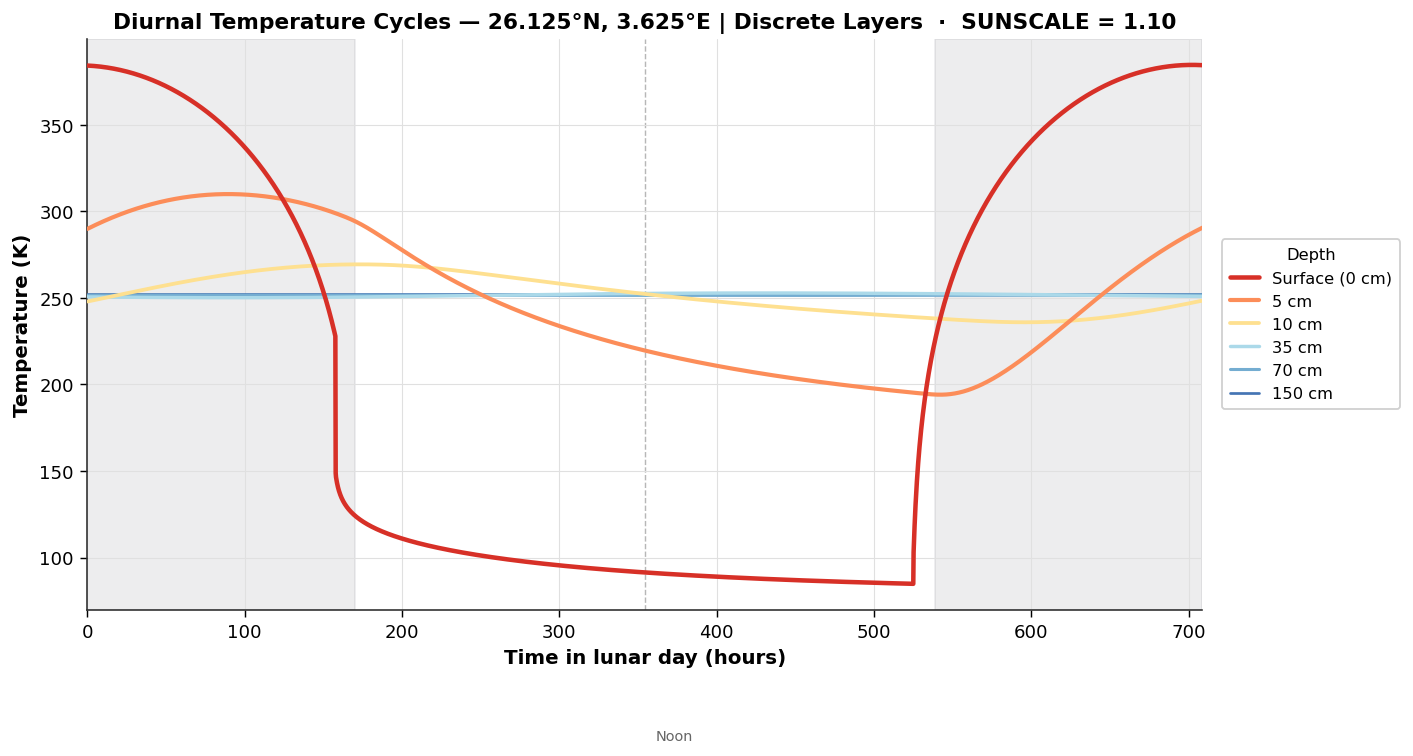

In [6]:
fig = plots.diurnal_cycles(
    CYCLES, ACTUAL_LAT, ACTUAL_LON,
    model_name=MODEL, sunscale=SUNSCALE,
)
plt.show()

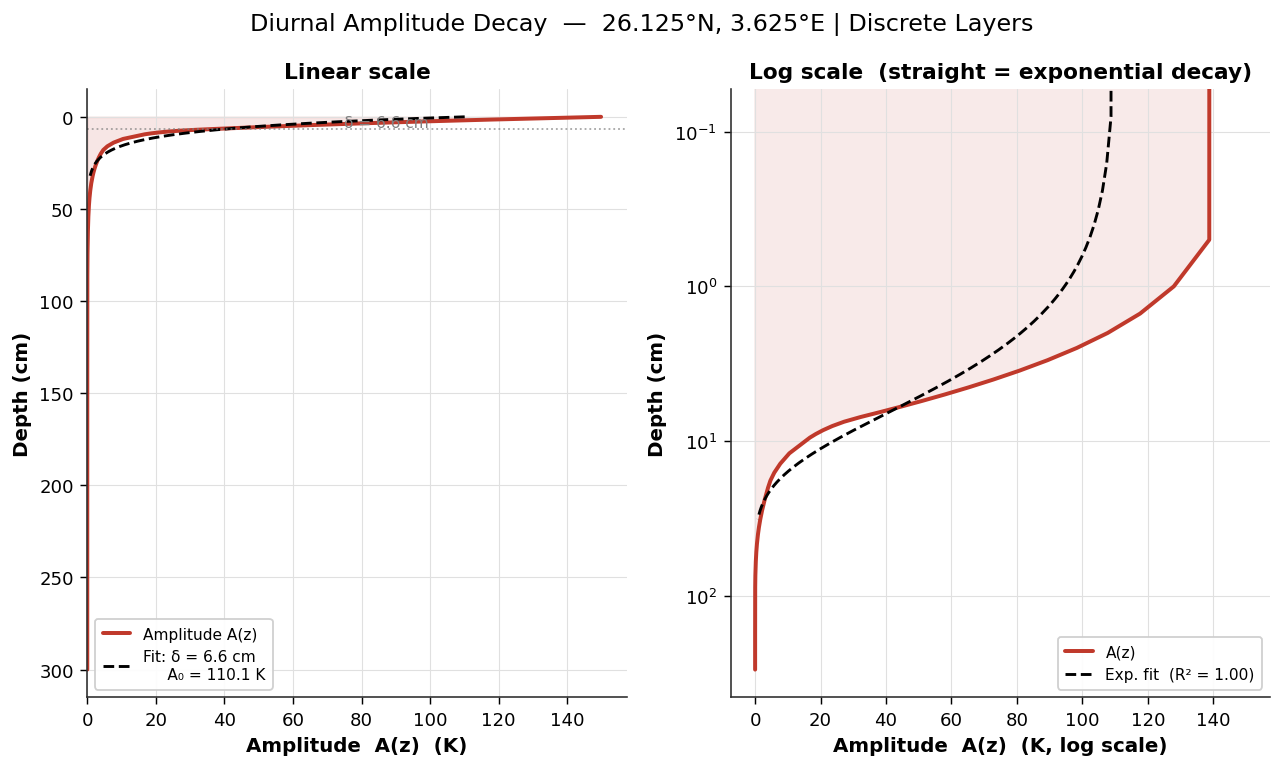

In [7]:
# Amplitude decay: A(z) = (T_max - T_min)/2 vs depth
# Log-linear plot should be straight if decay is purely exponential.
# Fit extracts thermal skin depth delta (cm).
fig = plots.amplitude_decay(
    STATS, Z_GRID, ACTUAL_LAT, ACTUAL_LON,
    model_name=MODEL,
)
plt.show()

---
## § 2 — Subsurface Temperature Heatmap  (Depth × Time)

Two-panel pcolormesh of T(z, t) for the final simulated lunar day:
- **Top panel**: full depth 0–1.5 m — shows exponential attenuation
- **Bottom panel**: zoomed 0–30 cm — reveals the propagating thermal wave

White iso-temperature contours are overlaid every ~30 K.

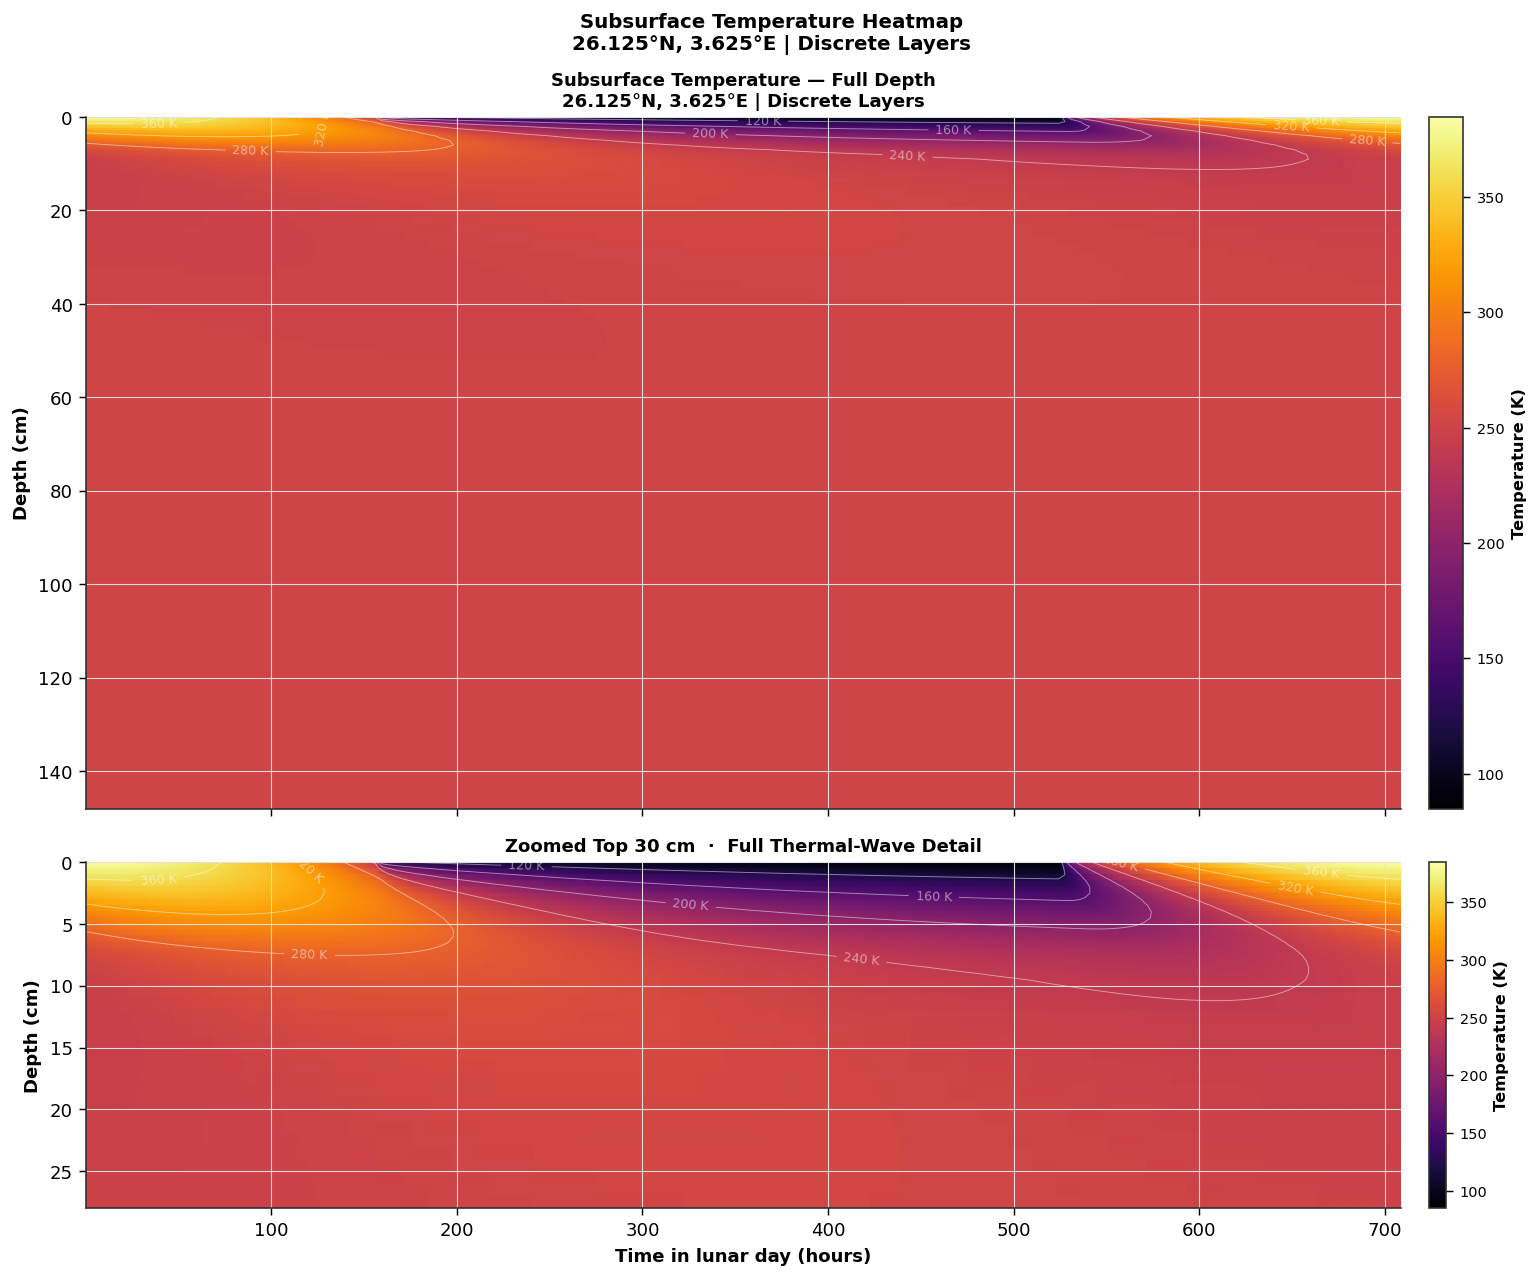

In [9]:
fig = plots.heatmap(
    T_PROFILE, T_ARR, Z_GRID,
    ACTUAL_LAT, ACTUAL_LON,
    model_name=MODEL,
    depth_limit=1.5,
    zoom_depth_cm=30,
    colormap='inferno',
    show_contours=True,
)
plt.show()

---
## § 3 — Analytical Surface Temperature Map

A fast analytical estimate of peak (noon) and nighttime surface temperatures across the local terrain window (±5°), using:

$$T_{\rm noon}(\phi) = \left(\frac{(1-A)\,S_0\,\cos\phi}{\varepsilon\,\sigma}\right)^{1/4}$$

The red star marks the simulated location; its model-derived T_max is annotated for comparison with the analytical estimate.

Full-model surface T_max = 384.6 K


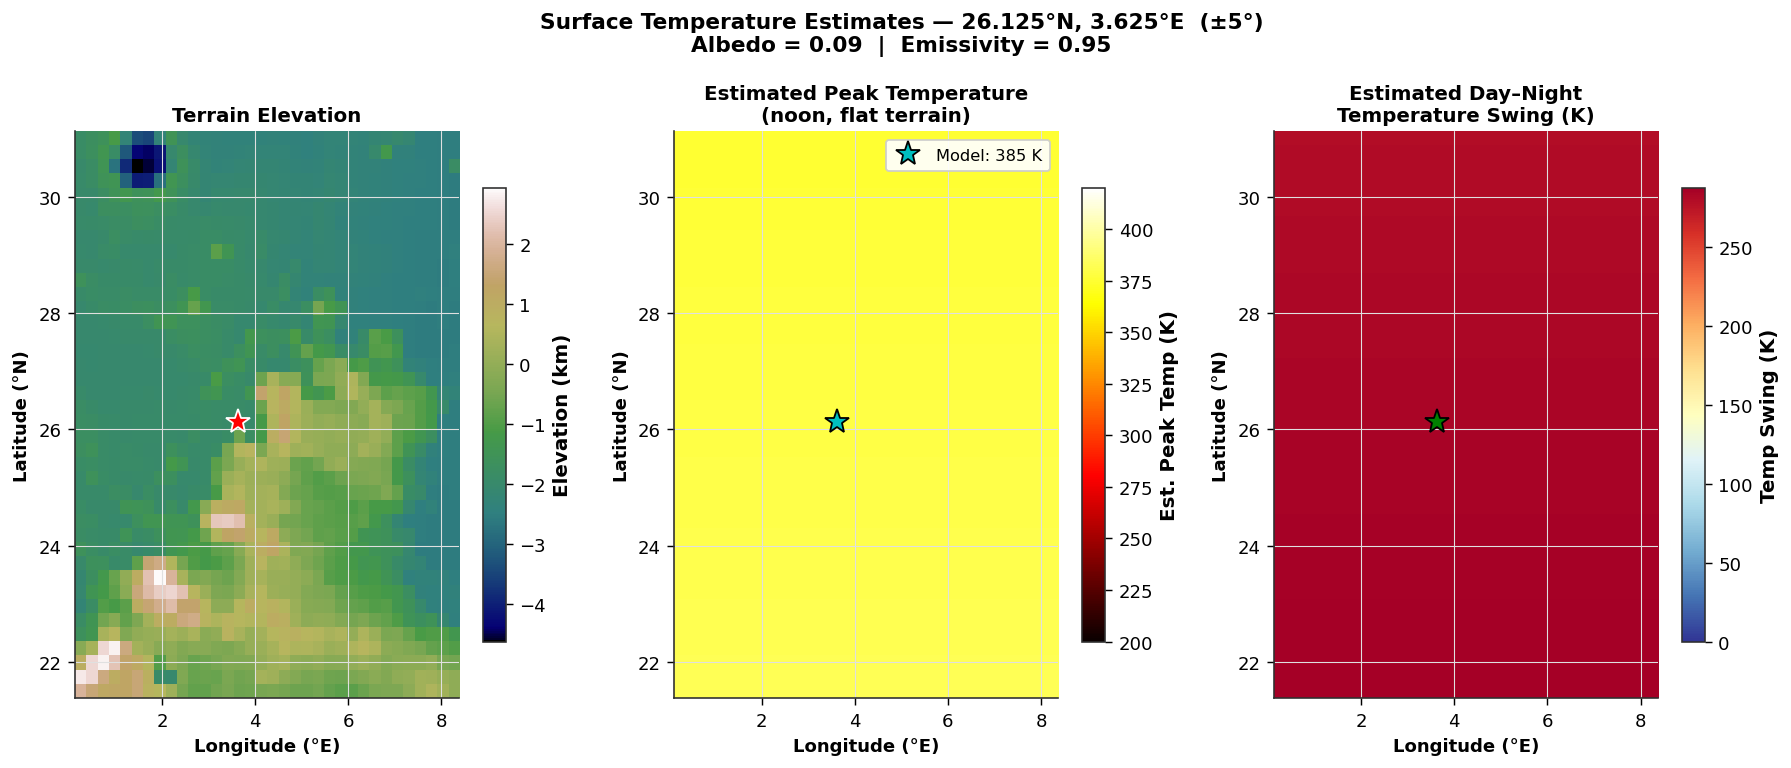

In [10]:
# T_simulated_max: surface peak from the full thermal solver
T_sim_max = float(T_PROFILE[:, 0].max())
print(f'Full-model surface T_max = {T_sim_max:.1f} K')

fig = plots.surface_temperature_map(
    ELEV_M, MAP_RES,
    target_lat=ACTUAL_LAT,
    target_lon=ACTUAL_LON,
    albedo=ALBEDO,
    emissivity=EMISSIVITY,
    window_deg=5,
    T_simulated_max=T_sim_max,
)
plt.show()

---
## § 4 — Apollo HFE Sensor Equilibration Timelines

The Apollo Heat Flow Experiment probes were emplaced by drilling, which deposited residual heat into the surrounding regolith. Sensors at shallower depths were also affected by the diurnal wave. The **rolling 60-day median** temperature reveals when each sensor equilibrated to its true undisturbed value.

- **Green band** = stable validation window used for model comparison
- **Flat line** = sensor has equilibrated; subsequent drift is real

Only deep sensors (≥ 80 cm) are shown — shallow sensors never fully equilibrate due to the diurnal perturbation.

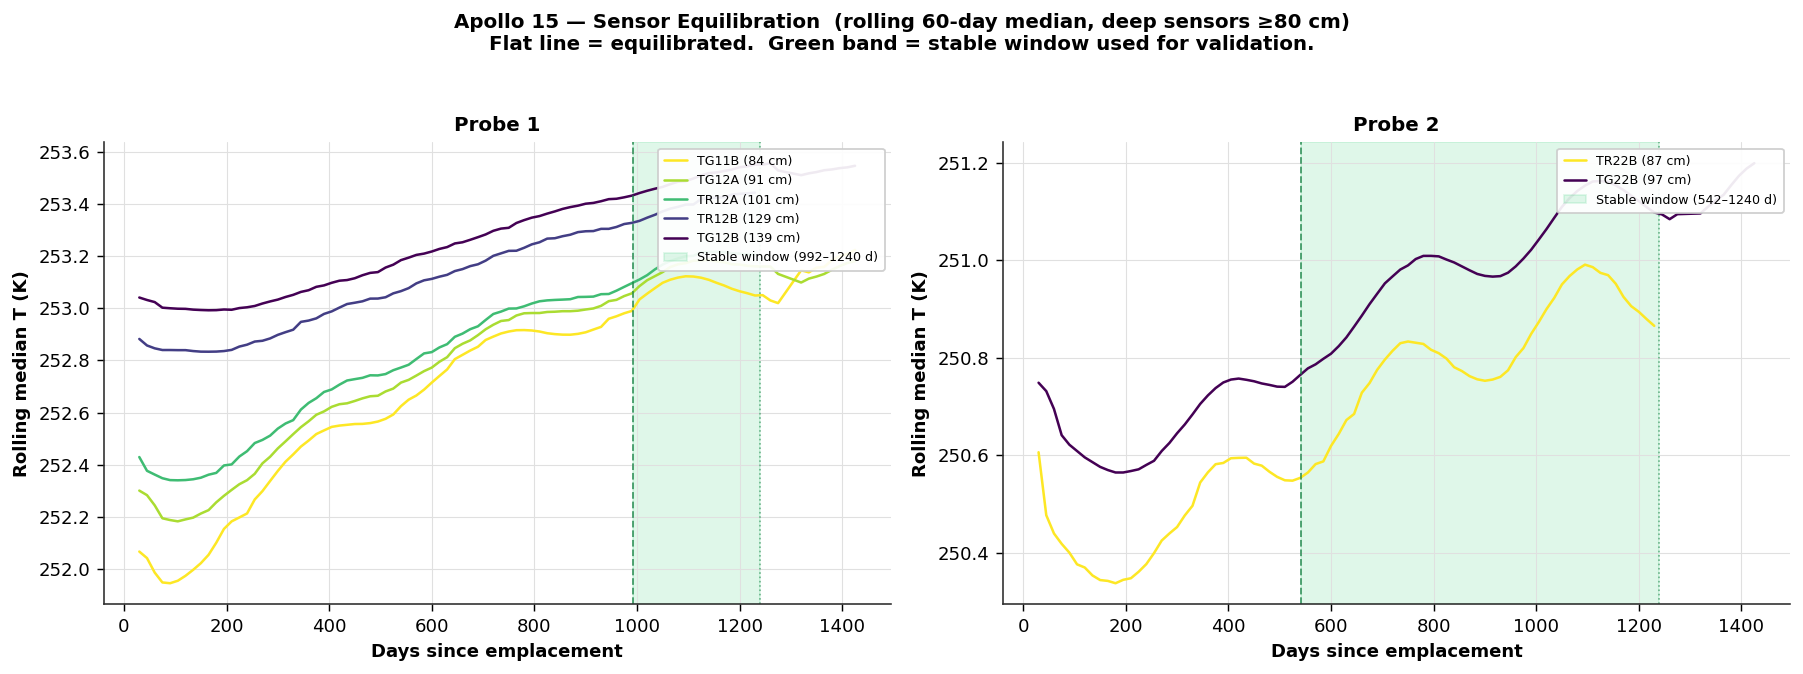

In [11]:
fig = plots.sensor_equilibration('Apollo 15')
plt.show()

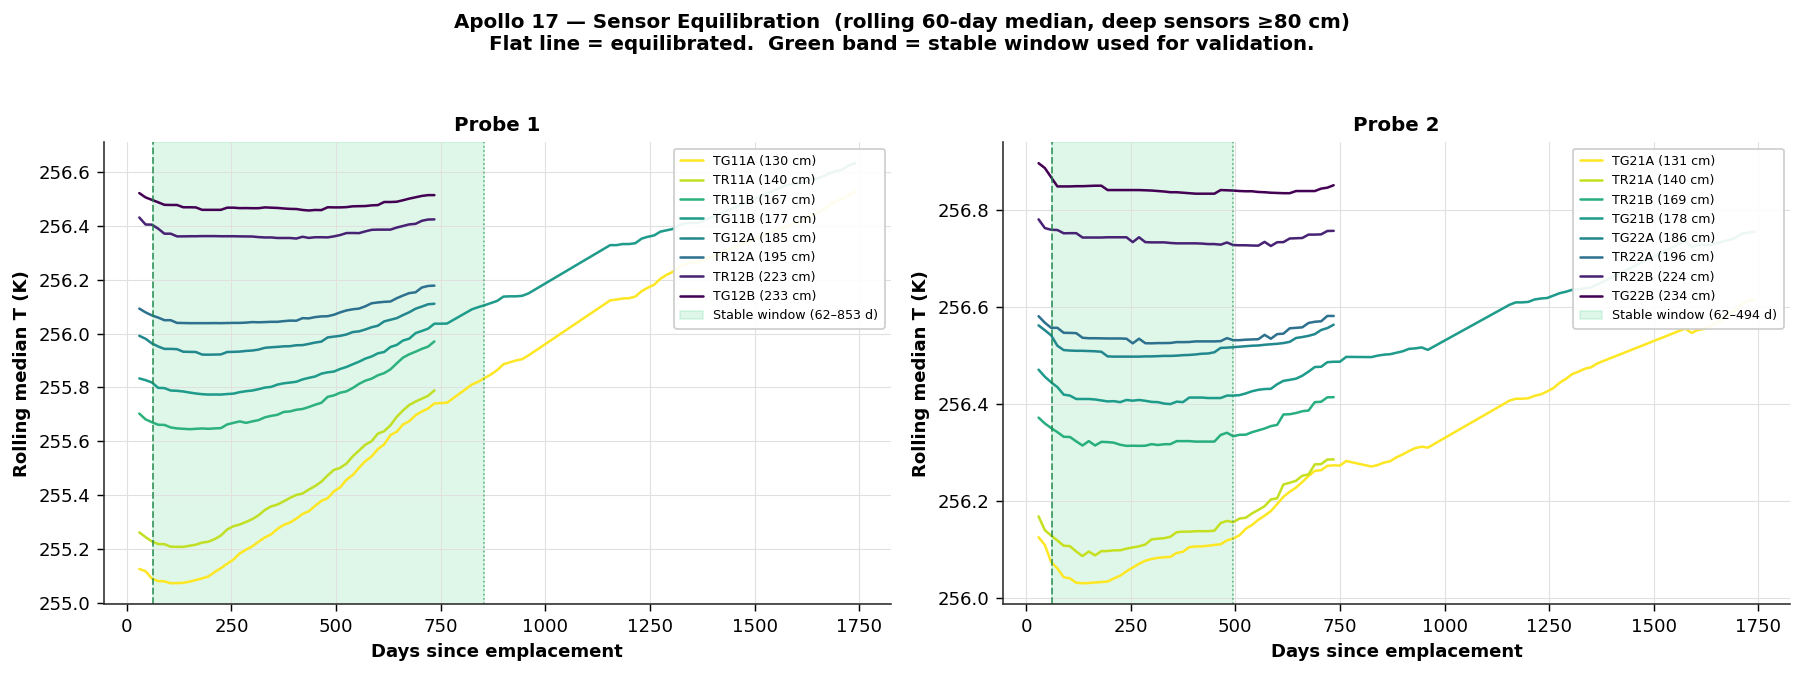

In [12]:
fig = plots.sensor_equilibration('Apollo 17')
plt.show()

---
## § 5 — Apollo HFE Validation

Comparing model mean-temperature profiles with equilibrium temperatures measured by the Apollo 15 and 17 Heat Flow Experiment probes.

**Sensor types** plotted with distinct markers:
| Symbol | Type | Description |
|--------|------|-------------|
| ● (filled circle) | **TG** | Gradient bridge — primary heat-flow sensor |
| ▲ (triangle) | **TR** | Reference thermocouple |
| ◆ (diamond) | **TC** | Cable thermometer (diurnal zone, <80 cm) |

The yellow band marks the diurnal zone (0–80 cm) where the model mean-temperature is influenced by the imperfect spin-up and should be interpreted with caution.

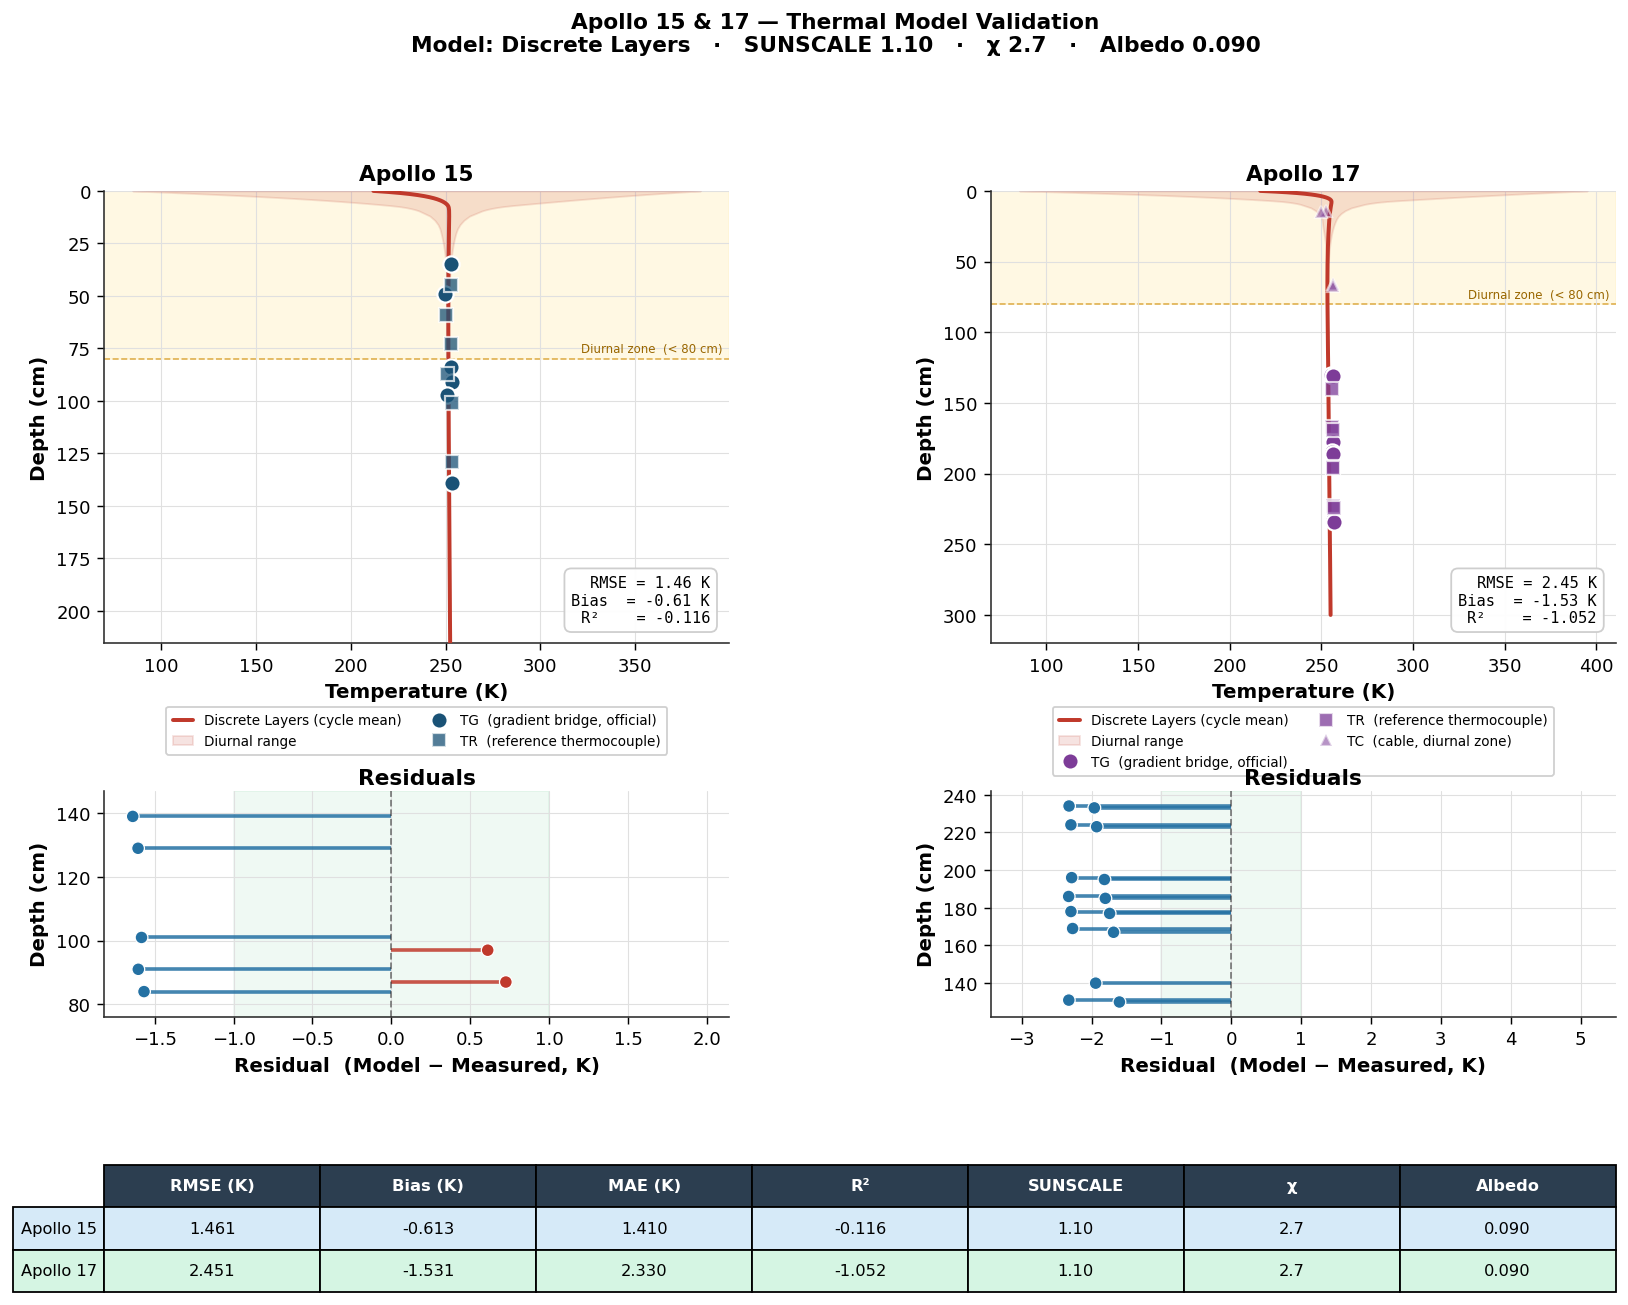

In [13]:
# Dual-site validation using the discrete-layer model
fig = plots.dual_apollo_comparison(
    APOLLO_RESULTS,
    model_name=MODEL,
    sunscale=SUNSCALE,
    chi=CHI,
    albedo=ALBEDO,
)
plt.show()

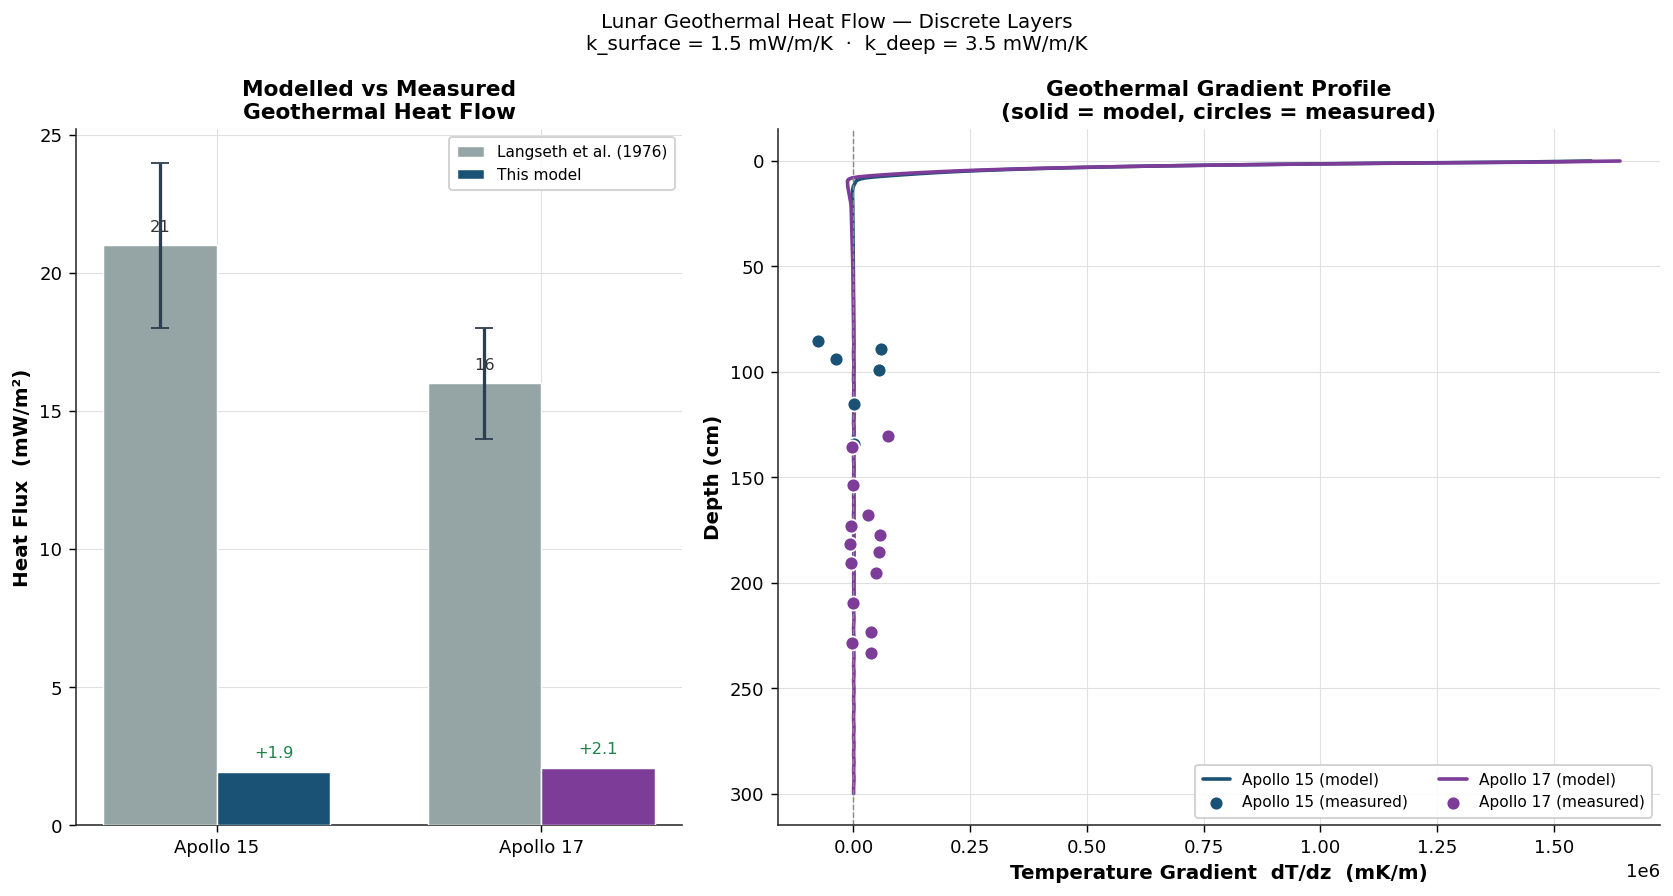

In [14]:
# Combined heat-flow summary: modelled vs Langseth (1976) reference
# Left panel: bar chart A15 vs A17
# Right panel: temperature gradient dT/dz vs depth
fig = plots.combined_heat_flow(
    APOLLO_RESULTS,
    model_name=MODEL,
)
plt.show()

---
## § 6 — Discrete vs Hayne 2017 Density Model Comparison

Two physically motivated regolith compaction models:

| Model | Density profile | k_solid at surface |
|-------|----------------|--------------------|
| **Discrete** | 3 sharp layers (Apollo drill cores) | 1.0×10⁻³ W/m/K |
| **Hayne 2017** | Smooth exponential ρ(z) (Diviner/infrared) | 7.4×10⁻⁴ W/m/K |

The models differ most in the **top 20 cm** where the fluffy-to-consolidated transition occurs. Both converge at depth.

Apollo measurement points are overlaid on each comparison.

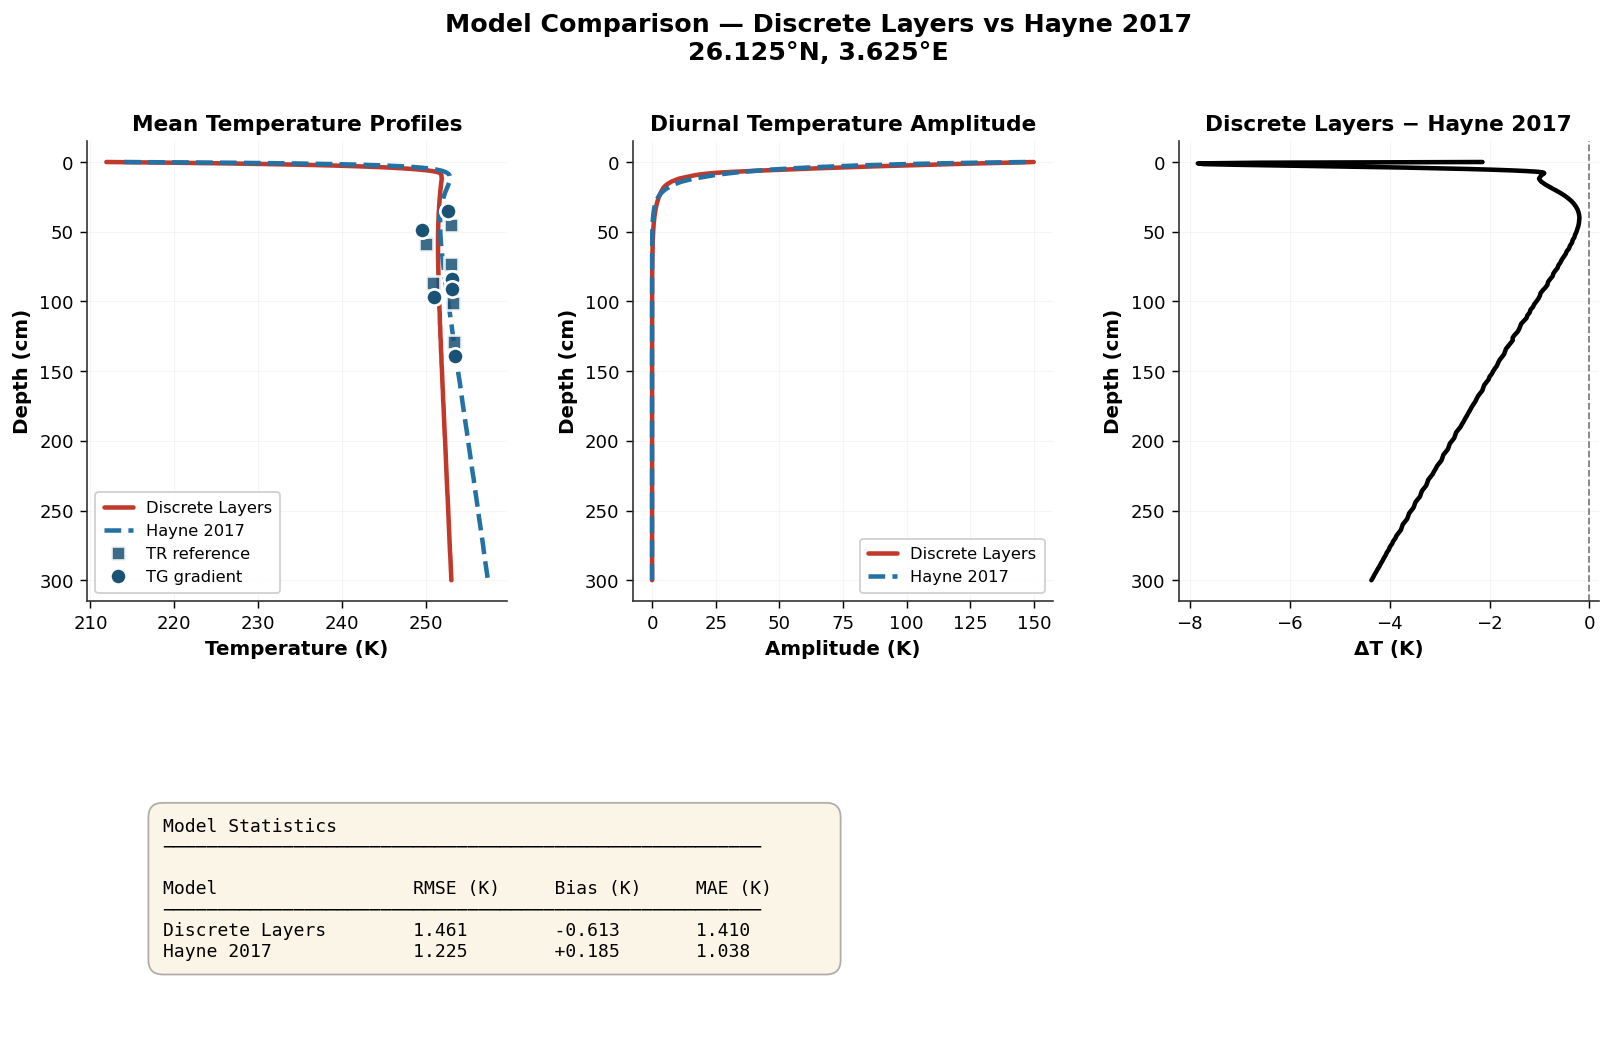

In [16]:
# ── Discrete vs Hayne 2017: Apollo 15 (left) and Apollo 17 (right) ─────────────
# Each panel shows mean T(z), T_min(z), T_max(z) vs Apollo HFE equilibrium data.
# RMSE and bias printed in legend.  Discrete = Apollo-calibrated; Hayne = Diviner-calibrated.

import matplotlib.pyplot as _plt2
import matplotlib.gridspec as _gs2

_fig_mc, _axes_mc = _plt2.subplots(1, 2, figsize=(18, 7), sharey=False)

for _ax_mc, (_site, _ap_d) in zip(_axes_mc, [
        ('Apollo 15', APOLLO_DATA['Apollo 15']),
        ('Apollo 17', APOLLO_DATA['Apollo 17'])
    ]):
    _inner_fig = plots.model_comparison(
        COMPARE_RESULTS[_site],
        Z_GRID,
        lat=_ap_d['lat'], lon=_ap_d['lon'],
        apollo_errors=COMPARE_ERRORS[_site],
    )
    # Copy axes from single figure into our combined axes
    import io as _io
    _plt2.close(_inner_fig)

# Fall back: just show each individually if single-figure copy is complex
_a15 = APOLLO_DATA['Apollo 15']
_a17 = APOLLO_DATA['Apollo 17']
_plt2.close(_fig_mc)

fig_mc15 = plots.model_comparison(
    COMPARE_RESULTS['Apollo 15'], Z_GRID,
    lat=_a15['lat'], lon=_a15['lon'],
    apollo_errors=COMPARE_ERRORS['Apollo 15'],
)
fig_mc15.suptitle('Model Comparison — Apollo 15', fontsize=13, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

fig_mc17 = plots.model_comparison(
    COMPARE_RESULTS['Apollo 17'], Z_GRID,
    lat=_a17['lat'], lon=_a17['lon'],
    apollo_errors=COMPARE_ERRORS['Apollo 17'],
)
fig_mc17.suptitle('Model Comparison — Apollo 17', fontsize=13, weight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('RMSE summary:')
for _site in ['Apollo 15', 'Apollo 17']:
    for _mk, _errs in COMPARE_ERRORS[_site].items():
        print(f'  {_site} ({_mk}): RMSE={_errs["rmse"]:.3f} K  bias={_errs["bias"]:.3f} K')

---
## § 7 — Probe Diurnal Cycles vs Both Density Models

Each Apollo probe recorded a small temperature oscillation over each synodic lunar day. The amplitude decreases rapidly with depth (e-folding ~5–12 cm). Comparing the **phase and amplitude** of these oscillations with both model predictions tests the near-surface thermal properties independently of the mean temperature.

Curves are shown as **temperature anomaly** T − ⟨T⟩ to remove absolute offsets and focus on phase alignment. The stable-window data is highlighted.

**Physical significance:** Phase lag between surface and sensor depth = z/δ × (P/2π), where δ is the skin depth. A phase-shifted model implies the wrong conductivity structure.

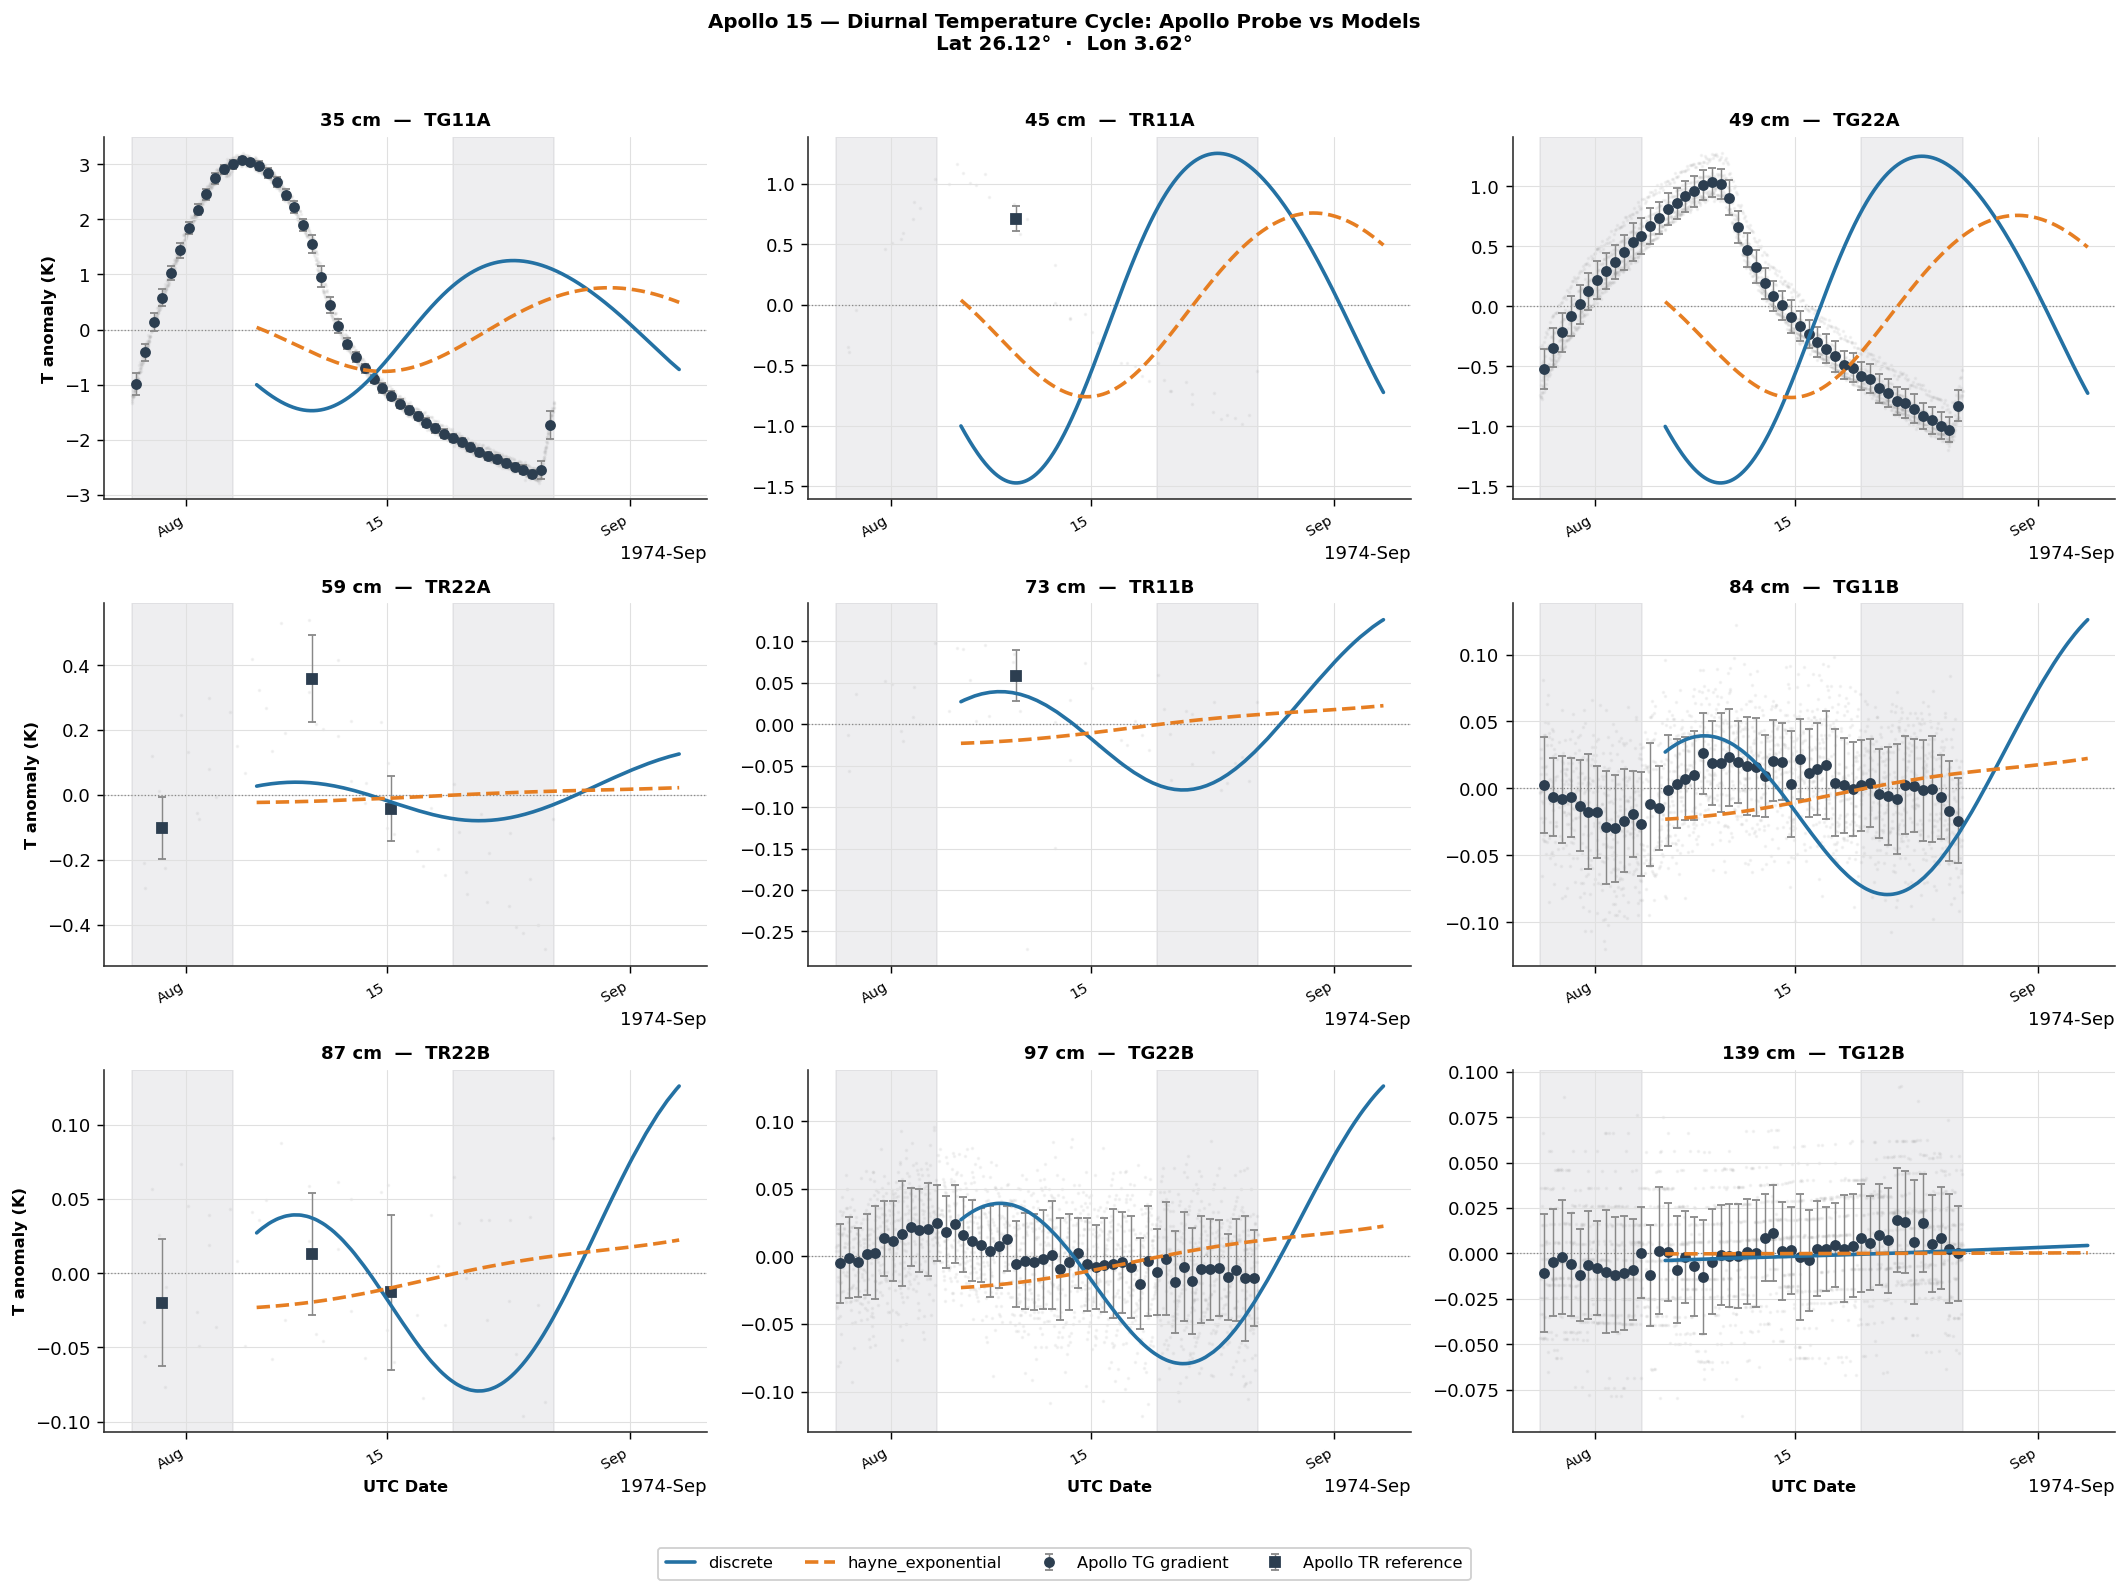

In [18]:
# Apollo 15 — probe diurnal anomaly vs discrete + Hayne models
probe15 = hfe_loader.get_probe_diurnal_cycle('Apollo 15', n_lunar_days=5)

# Use stored cycles from CELL-04 (same T_profile, same depths)
_cycles_disc_15  = APOLLO_DATA['Apollo 15']['disc']['cycles']
_cycles_hayne_15 = APOLLO_DATA['Apollo 15']['hayne']['cycles']

fig = plots.diurnal_probe_vs_models(
    probe15,
    _cycles_disc_15,
    _cycles_hayne_15,
    site_name='Apollo 15',
    lat=APOLLO_DATA['Apollo 15']['lat'],
    lon=APOLLO_DATA['Apollo 15']['lon'],
    model_name='discrete',
    hayne_name='hayne_exponential',
)
plt.show()

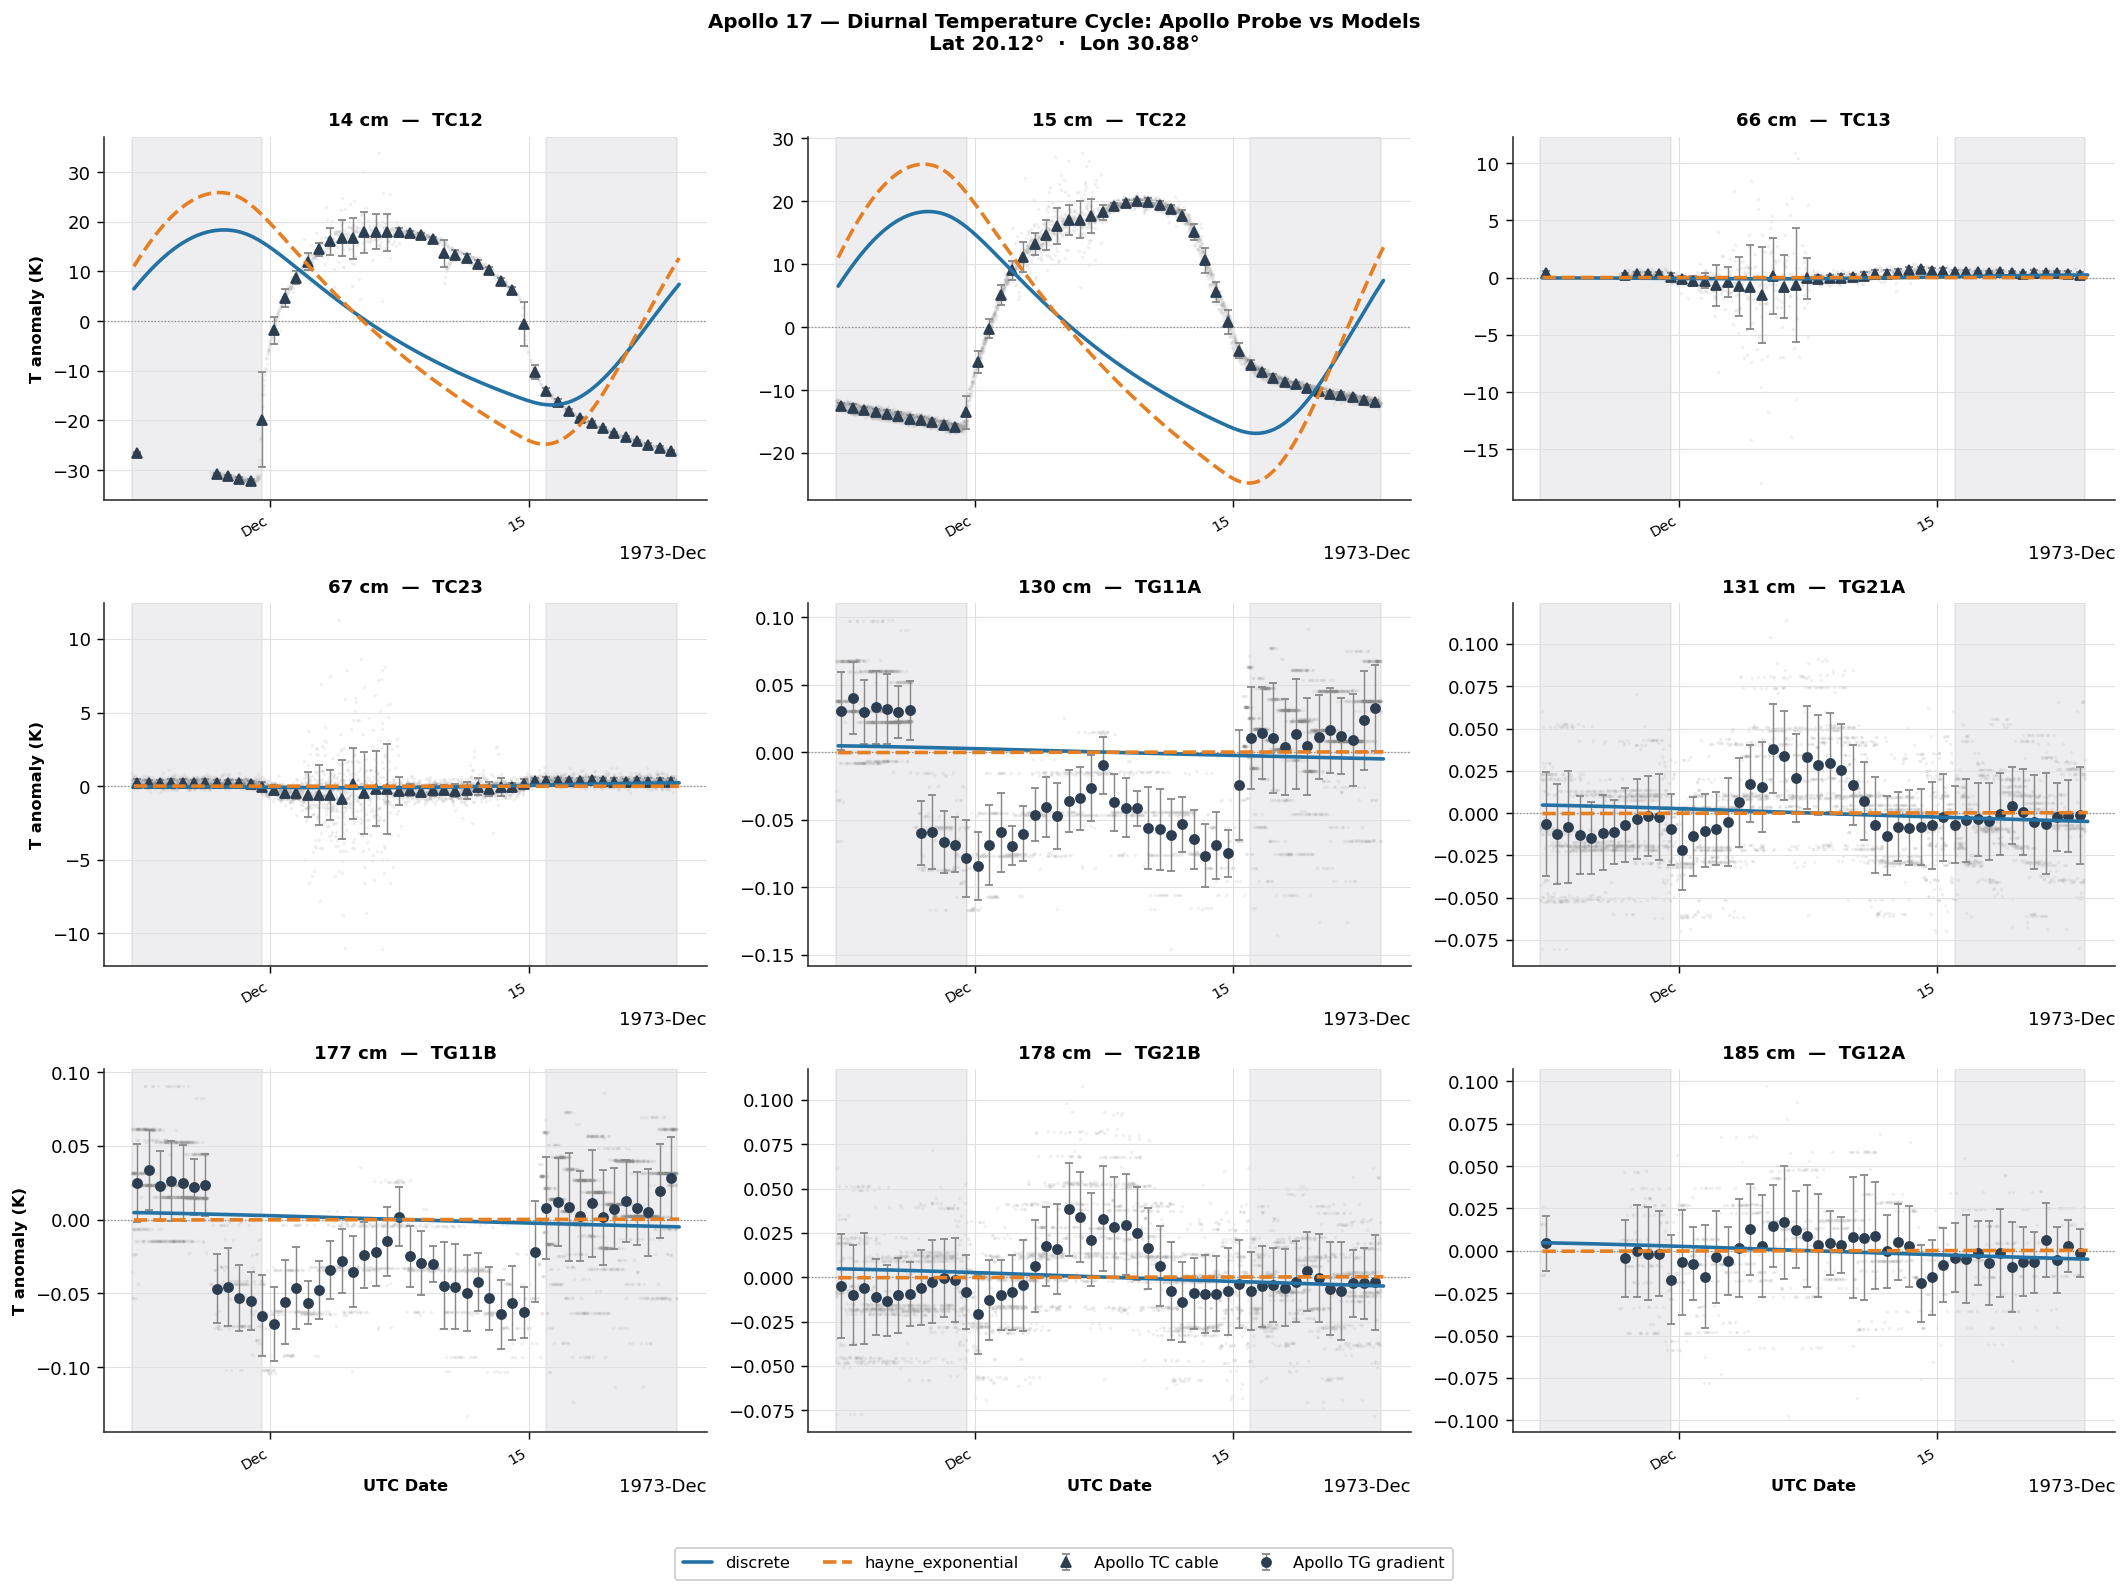

In [19]:
# Apollo 17 — probe diurnal anomaly vs discrete + Hayne models
probe17 = hfe_loader.get_probe_diurnal_cycle('Apollo 17', n_lunar_days=5)

_cycles_disc_17  = APOLLO_DATA['Apollo 17']['disc']['cycles']
_cycles_hayne_17 = APOLLO_DATA['Apollo 17']['hayne']['cycles']

fig = plots.diurnal_probe_vs_models(
    probe17,
    _cycles_disc_17,
    _cycles_hayne_17,
    site_name='Apollo 17',
    lat=APOLLO_DATA['Apollo 17']['lat'],
    lon=APOLLO_DATA['Apollo 17']['lon'],
    model_name='discrete',
    hayne_name='hayne_exponential',
)
plt.show()

---
## § 8 — Borestem Fiberglass Thermal Correction

The Apollo drill holes were lined with a hollow **fiberglass borestem** casing (OD = 2.5 cm, wall = 3 mm). Fiberglass has:

$$k_{\rm fg} \approx 0.04 \text{ W/m/K} \quad (\approx 40\times \text{ dry regolith surface conductivity})$$

This high-conductivity path short-circuits the temperature gradient, conducting heat from the warm surface layer to the sensors. The effective conductivity in the disturbed zone is:

$$k_{\rm eff}(z) = k_{\rm reg}(z)\,(1 - f) + k_{\rm fg}\,f$$

where $f = A_{\rm fg} / A_{\rm disturbed} \approx 0.013$ is the fiberglass area fraction.

The **warm bias** at each depth is estimated via the thermal-resistance perturbation method (1-D) and validated with the 2-D axisymmetric steady-state FD solver.

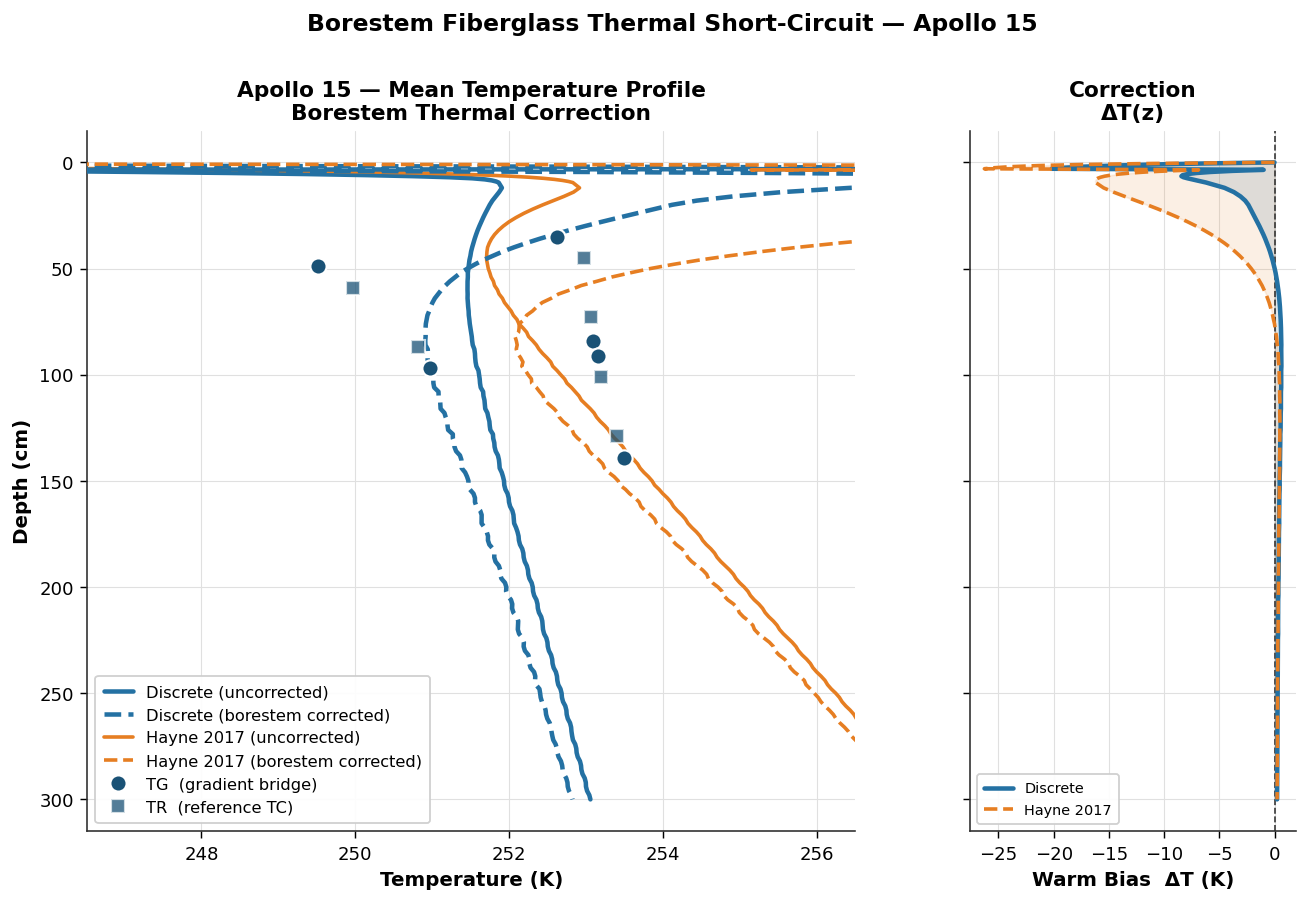

In [20]:
# ── Apollo 15: compute borestem + probe-top corrections ─────────────────
_s15_disc = APOLLO_DATA['Apollo 15']['disc']
_k15_disc = _s15_disc['k_profile']
_Tm15     = _s15_disc['stats']['T_mean']
_Ts15     = float(_Tm15[0])                # mean surface temperature
_Qs15     = borestem.mean_daytime_solar_flux(
    APOLLO_DATA['Apollo 15']['lat'], ALBEDO, SUNSCALE)

_, _corr_disc_15 = borestem.apply_all_corrections(
    _Tm15, Z_GRID, _k15_disc, _Ts15, _Qs15,
    use_2d_borestem=True,
)

_s15_hayne = APOLLO_DATA['Apollo 15']['hayne']
_k15_hayne = _s15_hayne['k_profile']
_Tm15h     = _s15_hayne['stats']['T_mean']
_Ts15h     = float(_Tm15h[0])
_, _corr_hayne_15 = borestem.apply_all_corrections(
    _Tm15h, Z_GRID, _k15_hayne, _Ts15h, _Qs15,
    use_2d_borestem=True,
)

# Build stats dict accepted by borestem_correction_plot
_bs_stats_15 = {**_s15_disc['stats'], 'z_grid': Z_GRID}
_err15 = _s15_disc['errors']
_apollo_data_15 = {
    'depths':       _err15['apollo_depths'],
    'T_K':          _err15['apollo_temps'],
    'sensor_types': _err15.get('apollo_sensor_types',
                               ['TG'] * len(_err15['apollo_depths'])),
}

fig = plots.borestem_correction_plot(
    stats             = _bs_stats_15,
    apollo_data       = _apollo_data_15,
    site_name         = '15',
    correction_dT     = _corr_disc_15['total'],
    hayne_T_model     = _Tm15h,
    hayne_correction_dT = _corr_hayne_15['total'],
)
plt.show()

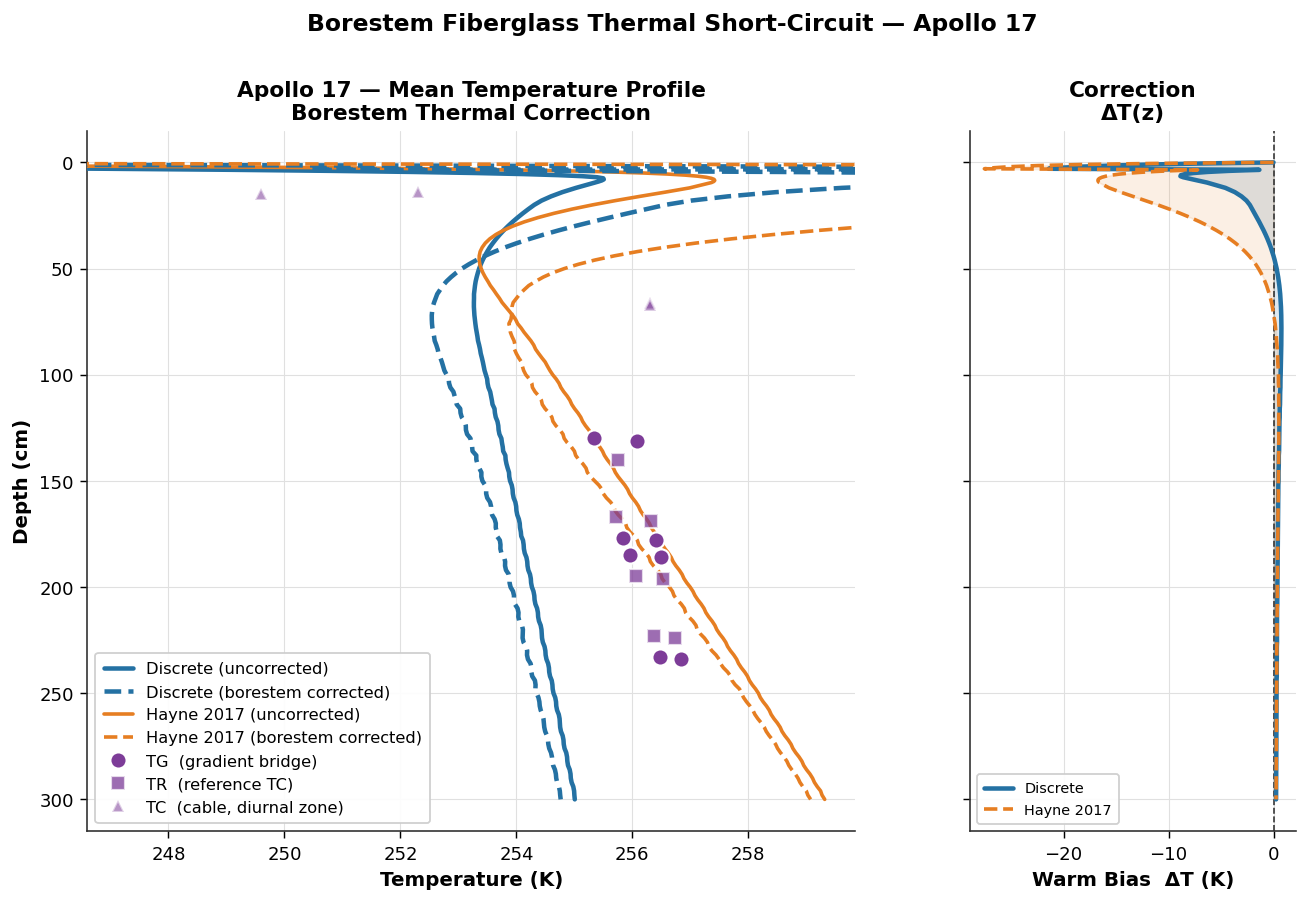

In [21]:
# ── Apollo 17: borestem correction ───────────────────────────────────────
_s17_disc = APOLLO_DATA['Apollo 17']['disc']
_k17_disc = _s17_disc['k_profile']
_Tm17     = _s17_disc['stats']['T_mean']
_Ts17     = float(_Tm17[0])
_Qs17     = borestem.mean_daytime_solar_flux(
    APOLLO_DATA['Apollo 17']['lat'], ALBEDO, SUNSCALE)

_, _corr_disc_17 = borestem.apply_all_corrections(
    _Tm17, Z_GRID, _k17_disc, _Ts17, _Qs17,
    use_2d_borestem=True,
)

_s17_hayne = APOLLO_DATA['Apollo 17']['hayne']
_k17_hayne = _s17_hayne['k_profile']
_Tm17h     = _s17_hayne['stats']['T_mean']
_Ts17h     = float(_Tm17h[0])
_, _corr_hayne_17 = borestem.apply_all_corrections(
    _Tm17h, Z_GRID, _k17_hayne, _Ts17h, _Qs17,
    use_2d_borestem=True,
)

_bs_stats_17 = {**_s17_disc['stats'], 'z_grid': Z_GRID}
_err17 = _s17_disc['errors']
_apollo_data_17 = {
    'depths':       _err17['apollo_depths'],
    'T_K':          _err17['apollo_temps'],
    'sensor_types': _err17.get('apollo_sensor_types',
                               ['TG'] * len(_err17['apollo_depths'])),
}

fig = plots.borestem_correction_plot(
    stats             = _bs_stats_17,
    apollo_data       = _apollo_data_17,
    site_name         = '17',
    correction_dT     = _corr_disc_17['total'],
    hayne_T_model     = _Tm17h,
    hayne_correction_dT = _corr_hayne_17['total'],
)
plt.show()

---
## § 9 — Borestem k_fiberglass Sensitivity Sweep

The fiberglass conductivity k_fg is a material property with some uncertainty depending on the glass-fibre/epoxy ratio and manufacturing tolerances. The nominal value k_fg = 0.04 W/m/K is well-constrained for E-glass composites, but exploring the range 0.01–0.30 W/m/K shows how sensitive the borestem correction is to this parameter.

The correction is proportional to the **thermal resistance contrast** $(R_{\rm reg} - R_{\rm eff})$, so higher k_fg → larger bias → larger downward correction needed.

Physics: $k_{\rm eff}(z) = k_{\rm reg}(z)\,(1-f) + k_{\rm fg}\,f$ inside the borestem depth, then $\Delta T = Q_{\rm surf} \cdot (R_{\rm reg} - R_{\rm eff})$.

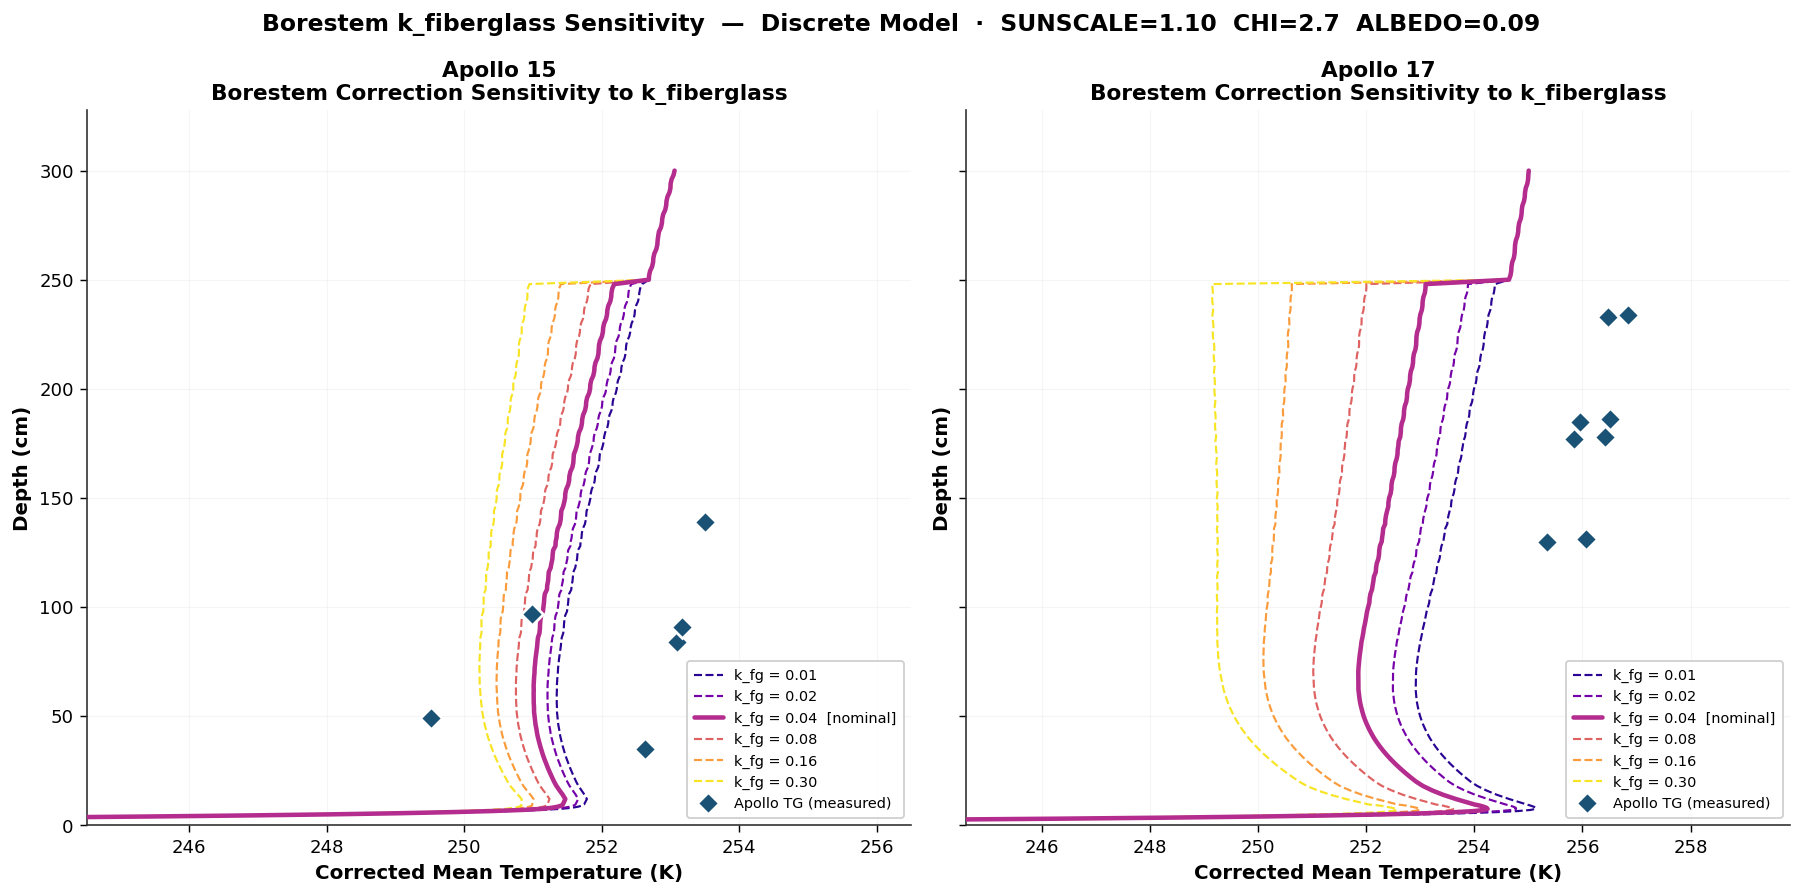

In [23]:
import matplotlib.cm as _cm

K_FG_SWEEP = [0.01, 0.02, 0.04, 0.08, 0.16, 0.30]  # W/m/K
NOMINAL_KFG = 0.04

from lunar.constants import BORESTEM_DEPTH_M

def _borestem_dT_custom_kfg(k_fg, z_grid, T_mean, k_profile):
    """Replicate borestem_temperature_correction with a custom k_fg."""
    f     = borestem.borestem_area_fraction()
    k_reg = np.asarray(k_profile, dtype=float)
    k_eff = k_reg.copy()
    mask  = z_grid <= BORESTEM_DEPTH_M
    k_eff[mask] = k_reg[mask] * (1.0 - f) + k_fg * f

    dz    = np.gradient(z_grid)
    R_reg = np.cumsum(dz / k_reg)
    R_eff = np.cumsum(dz / k_eff)

    # Estimate quasi-steady heat flux below the diurnal skin depth (~30 cm)
    iz_deep = np.searchsorted(z_grid, 0.30)
    iz_deep = min(iz_deep, len(z_grid) - 2)
    dz_deep = z_grid[iz_deep + 1] - z_grid[iz_deep]
    k_mid   = 0.5 * (k_reg[iz_deep] + k_reg[iz_deep + 1])
    Q_surf  = abs(k_mid * (float(T_mean[iz_deep + 1]) -
                           float(T_mean[iz_deep])) / dz_deep)
    if Q_surf < 1e-4:
        from lunar.constants import Q_basal
        Q_surf = abs(Q_basal)

    dT = Q_surf * (R_reg - R_eff)
    dT[z_grid > BORESTEM_DEPTH_M] = 0.0
    return dT

# ── Plot: one 2-panel figure (A15 left, A17 right) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
cmap = _cm.plasma
colors_sweep = [cmap(v) for v in np.linspace(0.05, 0.95, len(K_FG_SWEEP))]

for ax, site_name, T_mean, k_prof, err, site_id in [
    (axes[0], 'Apollo 15', _Tm15, _k15_disc, _err15, 'A15'),
    (axes[1], 'Apollo 17', _Tm17, _k17_disc, _err17, 'A17'),
]:
    a_d  = err['apollo_depths']
    a_T  = err['apollo_temps']
    st   = err.get('apollo_sensor_types', ['TG'] * len(a_d))
    st   = np.array(st)

    for k_fg, col in zip(K_FG_SWEEP, colors_sweep):
        dT      = _borestem_dT_custom_kfg(k_fg, Z_GRID, T_mean, k_prof)
        T_corr  = T_mean - dT
        lw      = 2.5 if abs(k_fg - NOMINAL_KFG) < 1e-6 else 1.2
        ls      = '-'  if abs(k_fg - NOMINAL_KFG) < 1e-6 else '--'
        label   = (f'k_fg = {k_fg:.2f}  [nominal]'
                   if abs(k_fg - NOMINAL_KFG) < 1e-6
                   else f'k_fg = {k_fg:.2f}')
        ax.plot(T_corr, Z_GRID * 100, color=col, lw=lw, ls=ls,
                label=label, zorder=3 if lw > 1.5 else 2)

    # Apollo data points (TG only for clarity)
    tg_mask = st == 'TG'
    if tg_mask.any():
        ax.plot(a_T[tg_mask], a_d[tg_mask] * 100,
                'D', color='#1A5276', markersize=9,
                markeredgewidth=1.5, markeredgecolor='white',
                zorder=8, label='Apollo TG (measured)')

    # Set axis limits zoomed to the measurement zone
    _pad = 3.0
    ax.set_xlim(float(a_T.min()) - _pad - 2, float(a_T.max()) + _pad)
    ax.set_ylim(float(a_d.max() * 100) * 1.4, 0)
    ax.invert_yaxis()
    ax.set_xlabel('Corrected Mean Temperature (K)', fontsize=11, weight='bold')
    ax.set_ylabel('Depth (cm)', fontsize=11, weight='bold')
    ax.set_title(f'{site_name}\n'
                 f'Borestem Correction Sensitivity to k_fiberglass',
                 fontsize=12, weight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Borestem k_fiberglass Sensitivity  —  '
    'Discrete Model  ·  '
    f'SUNSCALE={SUNSCALE:.2f}  CHI={CHI:.1f}  ALBEDO={ALBEDO:.2f}',
    fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

---
## § 10 — Animated T(z) Profile over One Lunar Day

Each frame shows the **depth profile T(z)** at one instant in the final simulated lunar day. The propagating thermal wave is clearly visible:

- **Dawn** (0–177 h): the near-surface warms from the left
- **Noon** (~354 h): surface at maximum temperature; wave front deepest
- **Dusk** (354–531 h): surface cools rapidly; deeper layers still warm
- **Night** (531–708 h): exponential cooling; deep layers isothermal

Colour encodes local solar time: **blue** = night, **orange** = day, **red** = noon.

The GIF is saved to `gifs/thermal_profile_animation.gif`.

In [24]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
from lunar.constants import LUNAR_DAY

# ── Extract last lunar day ────────────────────────────────────────────────
_t_start = T_ARR[-1] - LUNAR_DAY
_idx_day = np.where(T_ARR >= _t_start)[0]
_t_hours = (T_ARR[_idx_day] - _t_start) / 3600.0
_T_day   = T_PROFILE[_idx_day, :]        # (n_frames_raw, n_z)
_day_h   = LUNAR_DAY / 3600.0            # ~708 h

# Subsample to ~200 frames for a smooth, compact GIF
_step    = max(1, len(_idx_day) // 200)
_t_sel   = _t_hours[::_step]
_T_sel   = _T_day[::_step, :]
n_frames = len(_t_sel)

# Show only top 1.5 m where the thermal wave is visible
_iz_max  = np.searchsorted(Z_GRID, 1.5)
_z_cm    = Z_GRID[:_iz_max] * 100.0

# ── Colour map: local time → hue ──────────────────────────────────────────
# Blue=night, cyan=dawn, orange=day, red=noon
_cmap_time = plt.cm.twilight_shifted

def _time_color(t_h):
    """Map hour in lunar day to a colour (blue=night, orange=noon)."""
    phase = t_h / _day_h           # 0..1
    # noon at 0.5, night at 0 and 1
    return _cmap_time(phase)

# ── Figure setup ──────────────────────────────────────────────────────────
_fig_gif, _ax = plt.subplots(figsize=(6, 7))
_ax.set_xlabel('Temperature (K)', fontsize=12, weight='bold')
_ax.set_ylabel('Depth (cm)',       fontsize=12, weight='bold')
_ax.set_title(
    f'Propagating Thermal Wave — {ACTUAL_LAT:.3f}°N, {ACTUAL_LON:.3f}°E\n'
    f'{MODEL}  ·  SUNSCALE={SUNSCALE:.2f}',
    fontsize=11, weight='bold')
_ax.set_xlim(float(_T_sel[:, :_iz_max].min()) - 5,
             float(_T_sel[:, :_iz_max].max()) + 5)
_ax.set_ylim(_z_cm[-1] + 5, -2)
_ax.invert_yaxis()
_ax.grid(True, alpha=0.3)

# Skin depth reference line
_delta_cm = 10.0   # approximate lunar skin depth
_ax.axhline(_delta_cm, color='gray', ls=':', lw=1.2, alpha=0.7)
_ax.text(float(_T_sel[:, :_iz_max].min()) - 4, _delta_cm - 0.5,
         f'~δ = {_delta_cm:.0f} cm', fontsize=8, color='gray', va='bottom')

_line, = _ax.plot([], [], lw=2.5, color='gray')
_time_text = _ax.text(0.03, 0.96, '', transform=_ax.transAxes,
                      fontsize=10, va='top', family='monospace',
                      bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='white', alpha=0.85))

def _init():
    _line.set_data([], [])
    _time_text.set_text('')
    return _line, _time_text

def _update(frame):
    t = _t_sel[frame]
    T = _T_sel[frame, :_iz_max]
    col = _time_color(t)
    _line.set_data(T, _z_cm)
    _line.set_color(col)
    phase_name = ('Night'  if t < _day_h * 0.22 or t > _day_h * 0.78
                  else 'Dawn'  if t < _day_h * 0.38
                  else 'Dusk'  if t > _day_h * 0.62
                  else 'Noon')
    _time_text.set_text(f't = {t:5.0f} h  [{phase_name}]')
    return _line, _time_text

anim = FuncAnimation(
    _fig_gif, _update, frames=n_frames,
    init_func=_init, blit=True, interval=60,
)

# Save to GIF
_gif_path = 'gifs/thermal_profile_animation.gif'
print(f'Saving {n_frames}-frame GIF → {_gif_path} …', end=' ', flush=True)
anim.save(_gif_path, writer=PillowWriter(fps=15))
print('done')

plt.close(_fig_gif)
HTML(f'<img src="{_gif_path}" />')

Saving 201-frame GIF → gifs/thermal_profile_animation.gif … done


---
## § 11 — Animated Heatmap + Live T(z) Profile

A two-panel animation:

- **Left panel**: static T(z, t) heatmap (depth × time) with a   **vertical cursor** sweeping from left to right across the full   lunar day
- **Right panel**: live T(z) depth profile at the cursor time —   updates each frame

This visualisation makes the propagating thermal wave intuitive: watch the right panel as the cursor passes through noon — the surface spike is followed by a delayed, attenuated wave at depth.

Saved to `gifs/heatmap_animation.gif`.

In [25]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
from lunar.constants import LUNAR_DAY

# ── Prepare data (same last-day slice as GIF 1) ───────────────────────────
_t_start2 = T_ARR[-1] - LUNAR_DAY
_idx2     = np.where(T_ARR >= _t_start2)[0]
_t_h2     = (T_ARR[_idx2] - _t_start2) / 3600.0
_T_day2   = T_PROFILE[_idx2, :]          # (n_raw, n_z)
_day_h2   = LUNAR_DAY / 3600.0

# Depth limit: show top 1.5 m
_iz2      = np.searchsorted(Z_GRID, 1.5)
_z_cm2    = Z_GRID[:_iz2] * 100.0
_T_sub2   = _T_day2[:, :_iz2]           # (n_raw, n_z2)

# Subsample to ~180 cursor positions
_step2    = max(1, len(_idx2) // 180)
_t_cursor = _t_h2[::_step2]
_T_cursor = _T_sub2[::_step2, :]        # (n_frames, n_z2)
n_frames2 = len(_t_cursor)

# ── Figure layout ─────────────────────────────────────────────────────────
_fig2, (_ax_hm, _ax_prof) = plt.subplots(
    1, 2, figsize=(13, 6),
    gridspec_kw={'width_ratios': [2.2, 1]},
)
_fig2.subplots_adjust(wspace=0.05)

# ── Left: static heatmap ─────────────────────────────────────────────────
_T_min2 = float(_T_sub2.min())
_T_max2 = float(_T_sub2.max())
_ax_hm.pcolormesh(_t_h2, _z_cm2, _T_sub2.T,
                  cmap='inferno', shading='gouraud',
                  vmin=_T_min2, vmax=_T_max2)
_ax_hm.invert_yaxis()
_ax_hm.set_xlabel('Time in lunar day (h)', fontsize=11, weight='bold')
_ax_hm.set_ylabel('Depth (cm)',             fontsize=11, weight='bold')
_ax_hm.set_title(
    f'T(z, t) Heatmap  —  {ACTUAL_LAT:.3f}°N  ·  {MODEL}',
    fontsize=11, weight='bold')

# Cursor line (updates each frame)
_cursor_line = _ax_hm.axvline(
    _t_cursor[0], color='white', lw=1.8, ls='--', alpha=0.9, zorder=5)

# ── Right: live profile ───────────────────────────────────────────────────
_ax_prof.set_xlim(_T_min2 - 2, _T_max2 + 2)
_ax_prof.set_ylim(_z_cm2[-1] + 5, -2)
_ax_prof.invert_yaxis()
_ax_prof.set_xlabel('Temperature (K)', fontsize=11, weight='bold')
_ax_prof.yaxis.set_ticklabels([])
_ax_prof.set_title('T(z) profile', fontsize=11, weight='bold')
_ax_prof.grid(True, alpha=0.3)

_prof_line, = _ax_prof.plot([], [], lw=2.5, color='#FF7F00')
_time_ann   = _ax_prof.text(
    0.05, 0.97, '', transform=_ax_prof.transAxes,
    fontsize=9, va='top', family='monospace',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

def _init2():
    _cursor_line.set_xdata([_t_cursor[0], _t_cursor[0]])
    _prof_line.set_data([], [])
    _time_ann.set_text('')
    return _cursor_line, _prof_line, _time_ann

def _update2(frame):
    t  = _t_cursor[frame]
    Tz = _T_cursor[frame]
    _cursor_line.set_xdata([t, t])
    _prof_line.set_data(Tz, _z_cm2)
    # Colour cursor by local time (noon=red, night=blue)
    phase = t / _day_h2
    col   = plt.cm.twilight_shifted(phase)
    _cursor_line.set_color(col)
    _prof_line.set_color(col)
    _time_ann.set_text(f'{t:5.0f} h')
    return _cursor_line, _prof_line, _time_ann

anim2 = FuncAnimation(
    _fig2, _update2, frames=n_frames2,
    init_func=_init2, blit=True, interval=60,
)

_gif2_path = 'gifs/heatmap_animation.gif'
print(f'Saving {n_frames2}-frame GIF → {_gif2_path} …', end=' ', flush=True)
anim2.save(_gif2_path, writer=PillowWriter(fps=15))
print('done')

plt.close(_fig2)
HTML(f'<img src="{_gif2_path}" />')

Saving 189-frame GIF → gifs/heatmap_animation.gif … 

KeyboardInterrupt: 